## Step 1  Video Quality Assessment (Blur Detection, FPS, Resolution Check)

In [1]:
import cv2
import numpy as np
import mediapipe as mp
from pathlib import Path
import os
from tqdm import tqdm
from collections import deque
from typing import Optional, Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Step 2 ROI Detection & Tracking (Person Detection + Hand ROI Tracking + Pose ROI)

In [5]:
import cv2
import numpy as np
import mediapipe as mp
from pathlib import Path
import os
from tqdm import tqdm
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ROI TRACKER CLASS (with debug)
# ============================================================
class ROITracker:
    def __init__(self, roi_padding=0.4, smooth_factor=0.3, min_roi_size=20, max_roi_size_ratio=0.7):
        self.roi_padding = roi_padding
        self.smooth_factor = smooth_factor
        self.min_roi_size = min_roi_size
        self.max_roi_size_ratio = max_roi_size_ratio
        
        self.smoothed_center = None
        self.position_history = deque(maxlen=5)
        self.confidence_history = deque(maxlen=10)
        self.confidence_threshold = 0.3
        self.lost_frames = 0
        self.max_lost_frames = 10
        self.hand_size_history = deque(maxlen=10)
        self.avg_hand_size = None
        self.recovery_mode = False
        self.recovery_attempts = 0
        self.max_recovery_attempts = 3

    def _get_roi(self, frame, wrist_lm):
        h, w = frame.shape[:2]
        
        cx = int(wrist_lm.x * w)
        cy = int(wrist_lm.y * h)
        current_center = np.array([cx, cy])
        
        if self.smoothed_center is None:
            self.smoothed_center = current_center
        else:
            movement = np.linalg.norm(current_center - self.smoothed_center)
            if movement < 20:
                current_factor = self.smooth_factor * 0.5
            else:
                current_factor = self.smooth_factor
            
            self.smoothed_center = self.smoothed_center * (1 - current_factor) + current_center * current_factor
        
        hand_size = self._estimate_hand_size(wrist_lm, w, h)
        self.hand_size_history.append(hand_size)
        self.avg_hand_size = np.mean(self.hand_size_history) if len(self.hand_size_history) > 0 else hand_size
        
        base_size = int(self.avg_hand_size * (1 + self.roi_padding))
        min_size = max(self.min_roi_size, int(h * 0.05))
        max_size = int(h * self.max_roi_size_ratio)
        box = np.clip(base_size, min_size, max_size)
        
        cx_smooth, cy_smooth = int(self.smoothed_center[0]), int(self.smoothed_center[1])
        x1 = max(0, cx_smooth - box // 2)
        y1 = max(0, cy_smooth - box // 2)
        x2 = min(w, x1 + box)
        y2 = min(h, y1 + box)
        
        return frame[y1:y2, x1:x2], (x1, y1)

    def _estimate_hand_size(self, wrist_lm, w, h):
        return h * 0.2

    def _calculate_roi_confidence(self, hand_landmarks, roi_size):
        if not hand_landmarks:
            return 0.0
        
        landmarks = hand_landmarks[0].landmark
        edge_threshold = 0.1
        
        at_edge = False
        for lm in landmarks:
            if (lm.x < edge_threshold or lm.x > 1 - edge_threshold or
                lm.y < edge_threshold or lm.y > 1 - edge_threshold):
                at_edge = True
                break
        
        x_coords = [lm.x for lm in landmarks]
        y_coords = [lm.y for lm in landmarks]
        hand_width = max(x_coords) - min(x_coords)
        hand_height = max(y_coords) - min(y_coords)
        area_ratio = (hand_width * hand_height) / (roi_size * roi_size)
        
        confidence = 1.0
        if at_edge:
            confidence *= 0.3
        if area_ratio < 0.1:
            confidence *= 0.5
        elif area_ratio > 0.8:
            confidence *= 0.7
        
        return confidence

    def extract_hand_roi(self, frame, wrist_lm, hands_processor):
        """Extract hand ROI - returns (hand_features, confidence)"""
        if wrist_lm is None:
            return None, 0.0
        
        # Get ROI
        roi, offset = self._get_roi(frame, wrist_lm)
        
        h_r, w_r = roi.shape[:2]
        if h_r < self.min_roi_size or w_r < self.min_roi_size:
            return None, 0.0
        
        # Process ROI for hand detection
        try:
            rgb_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
            result = hands_processor.process(rgb_roi)
        except Exception as e:
            return None, 0.0
        
        if not result.multi_hand_landmarks:
            return None, 0.0
        
        # Extract landmarks
        h, w = frame.shape[:2]
        ox, oy = offset
        
        landmarks = result.multi_hand_landmarks[0].landmark
        pts = []
        for lm in landmarks:
            pts.extend([
                (lm.x * w_r + ox) / w,
                (lm.y * h_r + oy) / h,
                lm.z
            ])
        
        arr = np.array(pts, dtype=np.float32)
        
        # Normalize relative to wrist
        wrist_offset = arr[:3].copy()
        for i in range(0, len(arr), 3):
            arr[i:i+3] -= wrist_offset
        
        # Calculate confidence
        confidence = self._calculate_roi_confidence(
            result.multi_hand_landmarks, h_r
        )
        
        return arr, confidence



## Step 3 Landmark Extraction (MediaPipe Pose + Hands)

In [2]:
import cv2
import numpy as np
import mediapipe as mp
from pathlib import Path
import time

def compare_extraction_methods():
    """
    Compare ROI tracking vs Direct extraction on your videos
    """
    BASE_DIR = Path(r"D:\uni\Intern-1-Project\ksl")
    DATA_DIR = BASE_DIR / 'dataset' / 'annotated_videos_720p'
    test_class = 'កាតាប'
    
    test_path = DATA_DIR / test_class
    if not test_path.exists():
        print(f"❌ Class not found")
        return
    
    video_files = list(test_path.glob("*.mp4"))
    if not video_files:
        print(f"❌ No videos found")
        return
    
    test_video = video_files[0]
    print(f"\n📹 Testing on: {test_video.name}")
    print("=" * 60)
    
    # Initialize MediaPipe
    mp_holistic = mp.solutions.holistic
    mp_hands = mp.solutions.hands
    
    # Load frames
    cap = cv2.VideoCapture(str(test_video))
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    
    print(f"Total frames: {len(frames)}")
    print("\n" + "=" * 60)
    print("TESTING DIRECT EXTRACTION (MediaPipe Holistic)")
    print("=" * 60)
    
    # Test 1: Direct Extraction (Holistic)
    direct_results = test_direct_extraction(frames[:30])  # Test 30 frames
    
    print("\n" + "=" * 60)
    print("TESTING ROI-BASED EXTRACTION")
    print("=" * 60)
    
    # Test 2: ROI Extraction
    roi_results = test_roi_extraction(frames[:30])
    
    print("\n" + "=" * 60)
    print("COMPARISON RESULTS")
    print("=" * 60)
    print(f"Direct Extraction:")
    print(f"  - Hand detection rate: {direct_results['hand_rate']:.1%}")
    print(f"  - Avg confidence: {direct_results['avg_conf']:.2f}")
    print(f"  - Processing time: {direct_results['time']:.2f}s")
    print(f"  - Both hands detected: {direct_results['both_hands']} frames")
    
    print(f"\nROI Extraction:")
    print(f"  - Hand detection rate: {roi_results['hand_rate']:.1%}")
    print(f"  - Avg confidence: {roi_results['avg_conf']:.2f}")
    print(f"  - Processing time: {roi_results['time']:.2f}s")
    
    print("\n" + "=" * 60)
    print("RECOMMENDATION:")
    if direct_results['hand_rate'] >= roi_results['hand_rate']:
        print(" USE DIRECT EXTRACTION - Higher detection rate")
        print(f"   ({direct_results['hand_rate']:.1%} vs {roi_results['hand_rate']:.1%})")
    else:
        print(" USE ROI TRACKING - Higher detection rate")
        print(f"   ({roi_results['hand_rate']:.1%} vs {direct_results['hand_rate']:.1%})")
    
    if direct_results['time'] < roi_results['time']:
        print(f"   Also faster: {direct_results['time']:.2f}s vs {roi_results['time']:.2f}s")

def test_direct_extraction(frames):
    """Test direct MediaPipe extraction"""
    mp_holistic = mp.solutions.holistic
    
    results = {
        'hand_rate': 0,
        'avg_conf': 0,
        'time': 0,
        'both_hands': 0
    }
    
    start_time = time.time()
    hand_count = 0
    total_conf = 0
    
    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:
        
        for frame in frames:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = holistic.process(rgb)
            
            if result.left_hand_landmarks or result.right_hand_landmarks:
                hand_count += 1
                
                # Calculate confidence
                conf = 0
                if result.left_hand_landmarks:
                    conf += 0.5
                    # Check if right also detected
                    if result.right_hand_landmarks:
                        conf += 0.5
                        results['both_hands'] += 1
                
                total_conf += conf
    
    results['hand_rate'] = hand_count / len(frames)
    results['avg_conf'] = total_conf / hand_count if hand_count > 0 else 0
    results['time'] = time.time() - start_time
    
    return results

def test_roi_extraction(frames):
    """Test ROI-based extraction"""
    mp_hands = mp.solutions.hands
    mp_holistic = mp.solutions.holistic
    
    results = {
        'hand_rate': 0,
        'avg_conf': 0,
        'time': 0,
        'both_hands': 0
    }
    
    start_time = time.time()
    hand_count = 0
    total_conf = 0
    
    # Simple ROI tracker
    roi_size = 200
    smoothed_center = None
    
    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic, \
        mp_hands.Hands(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as hands:
        
        for frame in frames:
            h, w = frame.shape[:2]
            
            # Get pose to find wrist
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pose_result = holistic.process(rgb)
            
            # Try to get wrist
            if pose_result.pose_landmarks:
                # Get right wrist (index 16)
                wrist = pose_result.pose_landmarks.landmark[16]
                cx = int(wrist.x * w)
                cy = int(wrist.y * h)
                
                if smoothed_center is None:
                    smoothed_center = (cx, cy)
                else:
                    # Smooth position
                    smoothed_center = (
                        int(smoothed_center[0] * 0.7 + cx * 0.3),
                        int(smoothed_center[1] * 0.7 + cy * 0.3)
                    )
                
                # Get ROI
                x1 = max(0, smoothed_center[0] - roi_size // 2)
                y1 = max(0, smoothed_center[1] - roi_size // 2)
                x2 = min(w, x1 + roi_size)
                y2 = min(h, y1 + roi_size)
                
                roi = frame[y1:y2, x1:x2]
                
                if roi.shape[0] > 50 and roi.shape[1] > 50:
                    # Detect hands in ROI
                    rgb_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
                    hand_result = hands.process(rgb_roi)
                    
                    if hand_result.multi_hand_landmarks:
                        hand_count += 1
                        total_conf += 1.0  # Simple confidence
            else:
                # Fallback: full frame detection
                hand_result = hands.process(rgb)
                if hand_result.multi_hand_landmarks:
                    hand_count += 1
                    total_conf += 0.5
    
    results['hand_rate'] = hand_count / len(frames)
    results['avg_conf'] = total_conf / hand_count if hand_count > 0 else 0
    results['time'] = time.time() - start_time
    
    return results

# Run comparison
if __name__ == "__main__":
    compare_extraction_methods()


📹 Testing on: កាតាប_001.mp4
Total frames: 113

TESTING DIRECT EXTRACTION (MediaPipe Holistic)


AttributeError: 'SymbolDatabase' object has no attribute 'GetPrototype'

In [13]:
import cv2
import numpy as np
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SMART ADAPTIVE EXTRACTOR — FIXED
# ============================================================
class SmartAdaptiveExtractor:
    def __init__(self):
        self.detection_history        = deque(maxlen=10)
        self.hand_size_history        = deque(maxlen=10)
        self.frames_since_detection   = 0
        self.stats = {
            'normal'  : 0,
            'adaptive': 0,
            'failed'  : 0,
            'total'   : 0,
        }

    def _hand_size(self, results, h, w):
        sizes = []
        for lm_set in [results.left_hand_landmarks,
                        results.right_hand_landmarks]:
            if lm_set:
                xs = [lm.x * w for lm in lm_set.landmark]
                ys = [lm.y * h for lm in lm_set.landmark]
                sizes.append(max(max(xs)-min(xs), max(ys)-min(ys)))
        return np.mean(sizes) if sizes else 0

    def _has_hands(self, results):
        return bool(results.left_hand_landmarks
                    or results.right_hand_landmarks)

    def _scale_back(self, results, scale):
        for lm_set in [results.pose_landmarks,
                        results.left_hand_landmarks,
                        results.right_hand_landmarks]:
            if lm_set:
                for lm in lm_set.landmark:
                    lm.x /= scale
                    lm.y /= scale
        return results

    def extract(self, frame, holistic):
        h, w = frame.shape[:2]
        self.stats['total'] += 1

        # Try normal first
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = holistic.process(rgb)

        if self._has_hands(results):
            sz = self._hand_size(results, h, w)
            self.hand_size_history.append(sz)
            self.frames_since_detection = 0
            self.stats['normal'] += 1
            return results

        # Decide scale based on history
        self.frames_since_detection += 1
        avg_sz     = np.mean(self.hand_size_history) \
                     if self.hand_size_history else 0
        scales     = [1.3, 1.6, 2.0] if avg_sz < 80 else [1.3]

        for scale in scales:
            if scale * min(h, w) > 2000:
                continue
            up  = cv2.resize(frame, (int(w*scale), int(h*scale)),
                             interpolation=cv2.INTER_LINEAR)
            res = holistic.process(cv2.cvtColor(up, cv2.COLOR_BGR2RGB))
            if self._has_hands(res):
                self._scale_back(res, scale)
                self.stats['adaptive'] += 1
                return res

        self.stats['failed'] += 1
        return results

    def get_stats(self):
        t = max(self.stats['total'], 1)
        return {
            'normal_detection_rate'  : self.stats['normal']   / t,
            'adaptive_detection_rate': self.stats['adaptive'] / t,
            'failed_detection_rate'  : self.stats['failed']   / t,
        }


# ============================================================
# FEATURE EXTRACTION
# ============================================================
def extract_pose(pose_lm):
    if pose_lm is None:
        return np.zeros(132, dtype=np.float32)
    arr = np.array([[lm.x, lm.y, lm.z, lm.visibility]
                     for lm in pose_lm.landmark], dtype=np.float32)
    # Normalize relative to hip midpoint
    hip = (arr[23, :3] + arr[24, :3]) / 2
    arr[:, :3] -= hip
    return arr.flatten()

def extract_hand(hand_lm):
    if hand_lm is None:
        return np.zeros(63, dtype=np.float32)
    pts = np.array([[lm.x, lm.y, lm.z]
                     for lm in hand_lm.landmark], dtype=np.float32)
    return (pts - pts[0]).flatten()

def get_windows(total, size, step):
    wins = []
    for s in range(0, total - size + 1, step):
        wins.append(list(range(s, s + size)))
    # Always include last window
    last = total - size
    if not wins or wins[-1][0] != last:
        wins.append(list(range(last, last + size)))
    return wins

def pad_seq(arr, target):
    if arr.shape[0] >= target:
        return arr
    pad = np.tile(arr[-1:], (target - arr.shape[0], 1))
    return np.concatenate([arr, pad])


# ============================================================
# MAIN
# ============================================================
def extract_landmarks_smart():

    BASE_DIR     = Path(r"D:\uni\Intern-1-Project\ksl")
    DATA_DIR     = BASE_DIR / 'dataset' / 'annotated_videos_720p'
    LANDMARK_DIR = BASE_DIR / 'landmarks_30frames_smart'

    SELECTED_CLASSES = [
        'computer_clean'
    ]

    SEQ_LEN      = 30
    WINDOW_STEP  = 15
    USE_POSE     = True
    USE_HANDS    = True   # both hands
    USE_VELOCITY = True

    # ── Feature sizes ──────────────────────────────────────────
    POSE_FEAT  = 132 if USE_POSE  else 0
    HANDS_FEAT = 126 if USE_HANDS else 0  # 63 × 2 (left + right)
    BASE_FEAT  = POSE_FEAT + HANDS_FEAT
    TOTAL_FEAT = BASE_FEAT * 2 if USE_VELOCITY else BASE_FEAT

    print("="*60)
    print("SMART ADAPTIVE EXTRACTION")
    print("="*60)
    print(f"Pose features  : {POSE_FEAT}")
    print(f"Hands features : {HANDS_FEAT}  (left 63 + right 63)")
    print(f"Base per frame : {BASE_FEAT}")
    print(f"Total w/vel    : {TOTAL_FEAT}")
    print(f"Output shape   : ({SEQ_LEN}, {TOTAL_FEAT})")
    print("="*60)

    LANDMARK_DIR.mkdir(parents=True, exist_ok=True)

    all_classes = sorted([d.name for d in DATA_DIR.iterdir()
                           if d.is_dir()])
    targets     = [c for c in SELECTED_CLASSES if c in all_classes]

    if not targets:
        print("❌ No valid classes found!")
        print("Available:", all_classes[:10])
        return

    mp_holistic = mp.solutions.holistic

    for class_name in targets:
        class_path = DATA_DIR / class_name
        save_path  = LANDMARK_DIR / class_name
        save_path.mkdir(parents=True, exist_ok=True)

        # Skip if already done
        done = len(list(save_path.glob('*.npy')))
        if done > 0:
            print(f"Skipping {class_name} ({done} files exist)")
            continue

        videos  = sorted(list(class_path.glob('*.mp4')) +
                          list(class_path.glob('*.avi')))
        print(f"\n📹 {class_name}: {len(videos)} videos")

        extractor      = SmartAdaptiveExtractor()
        sample_counter = 0
        hand_detected  = 0
        videos_ok      = 0

        with mp_holistic.Holistic(
            static_image_mode        = False,
            model_complexity         = 1,
            min_detection_confidence = 0.3,
            min_tracking_confidence  = 0.3
        ) as holistic:

            for v_idx, video_file in enumerate(
                    tqdm(videos, desc=class_name)):

                cap    = cv2.VideoCapture(str(video_file))
                frames = []
                while True:
                    ret, frame = cap.read()
                    if not ret: break
                    frames.append(frame)
                cap.release()

                if len(frames) < SEQ_LEN // 2:
                    continue

                # ── Extract landmarks per frame ───────────────
                all_feats = []
                valid     = 0

                for frame in frames:
                    res = extractor.extract(frame, holistic)

                    pose_f  = extract_pose(res.pose_landmarks)
                    left_f  = extract_hand(res.left_hand_landmarks)
                    right_f = extract_hand(res.right_hand_landmarks)

                    combined = np.concatenate([pose_f, left_f, right_f])
                    # shape: (258,) = 132 + 63 + 63

                    has_hand = (res.left_hand_landmarks is not None
                                or res.right_hand_landmarks is not None)
                    if has_hand:
                        valid      += 1
                        hand_detected += 1

                    all_feats.append(combined)

                if valid == 0:
                    continue

                videos_ok += 1

                # ── Create overlapping windows ────────────────
                total   = len(all_feats)
                windows = get_windows(total, SEQ_LEN, WINDOW_STEP)

                for win in windows:
                    feats = [all_feats[i] for i in win
                             if i < len(all_feats)]
                    if len(feats) < SEQ_LEN // 2:
                        continue

                    pos = np.array(feats, dtype=np.float32)

                    # Pad if needed
                    if pos.shape[0] < SEQ_LEN:
                        pos = pad_seq(pos, SEQ_LEN)

                    # Add velocity
                    if USE_VELOCITY:
                        vel     = np.zeros_like(pos)
                        vel[1:] = pos[1:] - pos[:-1]
                        out     = np.concatenate([pos, vel], axis=1)
                    else:
                        out = pos

                    # ── Shape check ───────────────────────────
                    if out.shape != (SEQ_LEN, TOTAL_FEAT):
                        print(f"   Shape mismatch: {out.shape} "
                              f"expected ({SEQ_LEN},{TOTAL_FEAT})")
                        continue

                    # ── Quality gate ──────────────────────────
                    zero_ratio = np.mean(
                        np.all(out[:, POSE_FEAT:POSE_FEAT+63] == 0,
                               axis=1)
                    )
                    if zero_ratio > 0.6:
                        continue  # too many missing hand frames

                    np.save(save_path/f'{sample_counter:06d}.npy', out)
                    sample_counter += 1

                if (v_idx+1) % 10 == 0:
                    print(f"  Video {v_idx+1}/{len(videos)} | "
                          f"Samples so far: {sample_counter}")

        # Summary
        stats = extractor.get_stats()
        print(f"\n {class_name}:")
        print(f"   Videos OK    : {videos_ok}/{len(videos)}")
        print(f"   Samples saved: {sample_counter}")
        print(f"   Hand detected: {hand_detected} frames")
        print(f"   Normal detect: {stats['normal_detection_rate']:.1%}")
        print(f"   Adaptive det : {stats['adaptive_detection_rate']:.1%}")
        print(f"   Failed       : {stats['failed_detection_rate']:.1%}")

    print("\n" + "="*60)
    print("DONE!")
    print(f"Output: {LANDMARK_DIR}")
    print(f"Shape : ({SEQ_LEN}, {TOTAL_FEAT})")
    print("="*60)


if __name__ == '__main__':
    extract_landmarks_smart()

SMART ADAPTIVE EXTRACTION
Pose features  : 132
Hands features : 126  (left 63 + right 63)
Base per frame : 258
Total w/vel    : 516
Output shape   : (30, 516)

📹 computer_clean: 51 videos


computer_clean:  20%|█▉        | 10/51 [01:45<11:32, 16.89s/it]

  Video 10/51 | Samples so far: 82


computer_clean:  39%|███▉      | 20/51 [02:36<03:00,  5.82s/it]

  Video 20/51 | Samples so far: 162


...

  Video 40/51 | Samples so far: 315


computer_clean:  98%|█████████▊| 50/51 [07:46<00:19, 19.96s/it]

  Video 50/51 | Samples so far: 398


computer_clean: 100%|██████████| 51/51 [08:00<00:00,  9.43s/it]


 computer_clean:
   Videos OK    : 51/51
   Samples saved: 405
   Hand detected: 6122 frames
   Normal detect: 87.6%
   Adaptive det : 0.3%
   Failed       : 12.2%

DONE!
Output: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart
Shape : (30, 516)


## Step 4 Landmark Checking 

LANDMARK CONFIDENCE VALIDATION
DRY_RUN = False
Expected shape: (30, 516)
Max zero rate : 50%
Max jump      : 0.3

Good កុំព្យូទ័រ:
   Total   : 266
   Valid   : 263 (98.9%)
   Removed : 3
     high_zero_rate: 3

Good កៅអី:
   Total   : 353
   Valid   : 345 (97.7%)
   Removed : 8
     velocity_jump: 5
     high_zero_rate: 3

Good ក្ដារខៀន:
   Total   : 359
   Valid   : 359 (100.0%)
   Removed : 0

Good ខ្មៅដៃ:
   Total   : 574
   Valid   : 571 (99.5%)
   Removed : 3
     high_zero_rate: 3

Good ជ័រលុប:
   Total   : 401
   Valid   : 400 (99.8%)
   Removed : 1
     high_zero_rate: 1

Good ដីស:
   Total   : 434
   Valid   : 433 (99.8%)
   Removed : 1
     high_zero_rate: 1

Good តុ:
   Total   : 414
   Valid   : 406 (98.1%)
   Removed : 8
     high_zero_rate: 7
     velocity_jump: 1

Good ទឹកលុប:
   Total   : 810
   Valid   : 798 (98.5%)
   Removed : 12
     high_zero_rate: 12

Good នាយករង:
   Total   : 434
   Valid   : 430 (99.1%)
   Removed : 4
     high_zero_rate: 4

Good នាយិកា:
   Tot

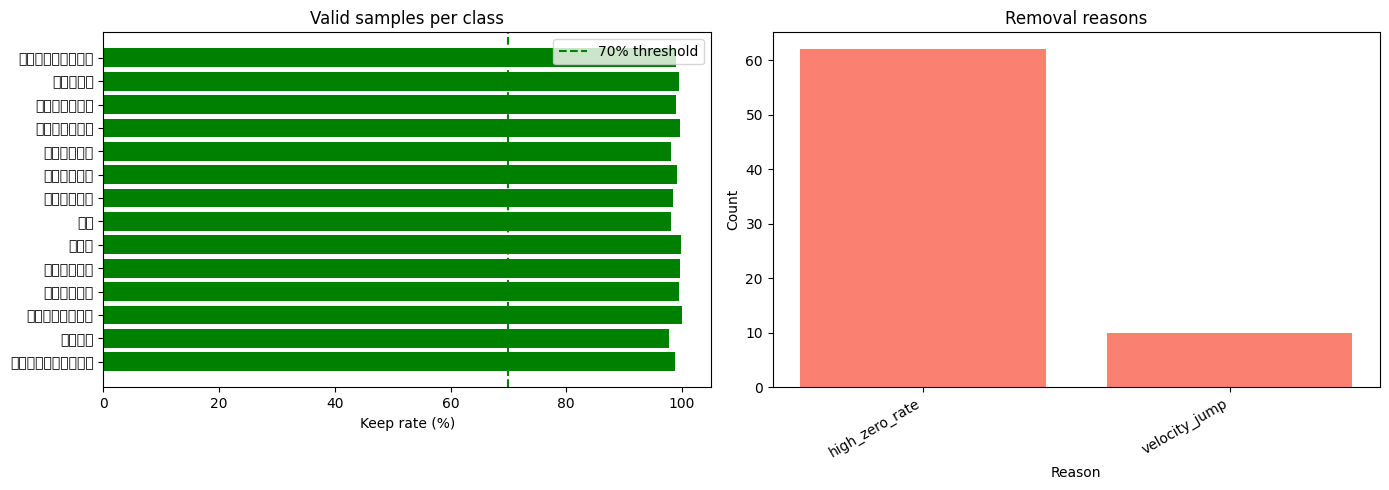

Chart saved to: D:\uni\Intern-1-Project\ksl\validation_report\validation_chart.png


In [3]:
import numpy as np
import os
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
LANDMARK_DIR   = Path(r"D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart")
REPORT_DIR     = Path(r"D:\uni\Intern-1-Project\ksl\validation_report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

SEQ_LEN        = 30
TOTAL_FEAT     = 516   # change to match your shape
POSE_FEAT      = 132
HAND_FEAT      = 63
LEFT_START     = POSE_FEAT
LEFT_END       = POSE_FEAT + HAND_FEAT          # 132:195
RIGHT_START    = LEFT_END
RIGHT_END      = RIGHT_START + HAND_FEAT        # 195:258
HALF           = TOTAL_FEAT // 2                # position vs velocity split

# ── Thresholds ────────────────────────────────────────────────
MAX_ZERO_RATIO      = 0.50   # max 50% frames with no hands
MAX_JUMP_THRESHOLD  = 0.30   # max position jump per frame (normalized)
MAX_VELOCITY_STD    = 0.15   # max std of velocity (frozen = 0, glitch = very high)
MIN_VELOCITY_STD    = 0.0001 # min std (if 0 = frozen sequence)
MIN_VALUE           = -2.0   # min feature value (after wrist normalization)
MAX_VALUE           =  2.0   # max feature value

DRY_RUN = False  # set False to actually delete files

# ============================================================
# VALIDATION FUNCTIONS
# ============================================================

def check_zero_rate(seq):
    """Check how many frames have no hand detected"""
    pos       = seq[:, :HALF]
    left_zero = np.all(pos[:, LEFT_START:LEFT_END]   == 0, axis=1)
    righ_zero = np.all(pos[:, RIGHT_START:RIGHT_END] == 0, axis=1)
    both_zero = left_zero & righ_zero
    return float(np.mean(both_zero))


def check_value_range(seq):
    """Check for values outside physically possible range"""
    pos     = seq[:, :HALF]
    # Only check hand regions (pose can be outside due to normalization)
    hands   = pos[:, LEFT_START:RIGHT_END]
    has_bad = (hands < MIN_VALUE).any() or (hands > MAX_VALUE).any()
    max_val = float(hands.max())
    min_val = float(hands.min())
    return has_bad, min_val, max_val


def check_velocity_jumps(seq):
    """Check for impossible frame-to-frame jumps"""
    pos      = seq[:, :HALF]
    hands    = pos[:, LEFT_START:RIGHT_END]

    # Only check frames where hands are detected
    nonzero  = ~np.all(hands == 0, axis=1)
    if nonzero.sum() < 3:
        return 0.0, 0.0

    hands_nz = hands[nonzero]
    vel      = np.abs(np.diff(hands_nz, axis=0))
    max_jump = float(vel.max())
    avg_jump = float(vel.mean())
    return max_jump, avg_jump


def check_frozen(seq):
    """Check if sequence is frozen (no movement at all)"""
    vel      = seq[:, HALF:]   # velocity half
    vel_std  = float(np.std(vel))
    is_frozen = vel_std < MIN_VELOCITY_STD
    return is_frozen, vel_std


def check_velocity_noise(seq):
    """Check if velocity is unrealistically noisy (extraction glitch)"""
    vel     = seq[:, HALF:]
    vel_std = float(np.std(vel))
    is_noisy = vel_std > MAX_VELOCITY_STD
    return is_noisy, vel_std


def validate_sequence(seq, filename=""):
    """
    Run all checks on one sequence.
    Returns (is_valid, reasons_dict)
    """
    reasons = {}
    passed  = True

    # 1. Shape check
    if seq.shape != (SEQ_LEN, TOTAL_FEAT):
        reasons['wrong_shape'] = f"{seq.shape} != ({SEQ_LEN},{TOTAL_FEAT})"
        return False, reasons

    # 2. Zero rate
    zero_rate = check_zero_rate(seq)
    if zero_rate > MAX_ZERO_RATIO:
        reasons['high_zero_rate'] = f"{zero_rate:.1%} frames missing hands"
        passed = False

    # 3. Value range
    bad_range, min_v, max_v = check_value_range(seq)
    if bad_range:
        reasons['bad_value_range'] = f"min={min_v:.3f} max={max_v:.3f}"
        passed = False

    # 4. Velocity jumps
    max_jump, avg_jump = check_velocity_jumps(seq)
    if max_jump > MAX_JUMP_THRESHOLD:
        reasons['velocity_jump'] = \
            f"max jump={max_jump:.4f} > {MAX_JUMP_THRESHOLD}"
        passed = False

    # 5. Frozen sequence
    is_frozen, vel_std = check_frozen(seq)
    if is_frozen:
        reasons['frozen'] = f"vel_std={vel_std:.6f} (no movement)"
        passed = False

    # 6. Noisy velocity
    is_noisy, vel_std = check_velocity_noise(seq)
    if is_noisy:
        reasons['noisy_velocity'] = f"vel_std={vel_std:.4f} > {MAX_VELOCITY_STD}"
        # Warning only — don't fail on this alone
        reasons['_warning_noisy'] = True

    return passed, reasons


# ============================================================
# MAIN VALIDATION
# ============================================================
print("="*60)
print("LANDMARK CONFIDENCE VALIDATION")
print("="*60)
print(f"DRY_RUN = {DRY_RUN}")
print(f"Expected shape: ({SEQ_LEN}, {TOTAL_FEAT})")
print(f"Max zero rate : {MAX_ZERO_RATIO:.0%}")
print(f"Max jump      : {MAX_JUMP_THRESHOLD}")
print("="*60)

total_files    = 0
total_valid    = 0
total_removed  = 0
fail_reasons   = defaultdict(int)
class_summary  = {}

for class_name in sorted(os.listdir(LANDMARK_DIR)):
    class_path = LANDMARK_DIR / class_name
    if not class_path.is_dir(): continue

    files = sorted([f for f in os.listdir(class_path)
                    if f.endswith('.npy')])
    if not files: continue

    valid_count  = 0
    remove_count = 0
    class_fails  = defaultdict(int)

    for fname in files:
        fpath = class_path / fname
        total_files += 1

        try:
            seq = np.load(str(fpath))
        except Exception as e:
            print(f"  ❌ Cannot load {fname}: {e}")
            remove_count += 1
            fail_reasons['corrupt_file'] += 1
            if not DRY_RUN:
                fpath.unlink()
            continue

        is_valid, reasons = validate_sequence(seq, fname)

        if is_valid:
            valid_count  += 1
            total_valid  += 1
        else:
            remove_count += 1
            total_removed += 1
            for r in reasons:
                if not r.startswith('_'):
                    fail_reasons[r]    += 1
                    class_fails[r]     += 1
            if not DRY_RUN:
                fpath.unlink()

    keep_rate = valid_count / len(files) * 100 if files else 0
    status    = "Good" if keep_rate >= 70 else "Warming" if keep_rate >= 40 else "Bad"

    class_summary[class_name] = {
        'total'  : len(files),
        'valid'  : valid_count,
        'removed': remove_count,
        'rate'   : keep_rate,
        'fails'  : dict(class_fails)
    }

    print(f"\n{status} {class_name}:")
    print(f"   Total   : {len(files)}")
    print(f"   Valid   : {valid_count} ({keep_rate:.1f}%)")
    print(f"   Removed : {remove_count}")
    if class_fails:
        for reason, count in class_fails.items():
            print(f"     {reason}: {count}")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
print(f"Total files   : {total_files}")
print(f"Valid files   : {total_valid} ({total_valid/total_files*100:.1f}%)")
print(f"Removed files : {total_removed} ({total_removed/total_files*100:.1f}%)")

print(f"\nFail reasons:")
for reason, count in sorted(fail_reasons.items(),
                             key=lambda x: -x[1]):
    print(f"  {reason:30s}: {count}")

print(f"\nDRY_RUN = {DRY_RUN}")
if DRY_RUN:
    print("→ No files were deleted. Set DRY_RUN=False to delete.")
else:
    print("→ Invalid files have been deleted.")

# ============================================================
# SAVE REPORT
# ============================================================
report = {
    'summary': {
        'total'  : total_files,
        'valid'  : total_valid,
        'removed': total_removed,
        'rate'   : total_valid/total_files*100 if total_files else 0
    },
    'fail_reasons': dict(fail_reasons),
    'thresholds'  : {
        'max_zero_ratio'    : MAX_ZERO_RATIO,
        'max_jump'          : MAX_JUMP_THRESHOLD,
        'max_velocity_std'  : MAX_VELOCITY_STD,
        'min_velocity_std'  : MIN_VELOCITY_STD,
        'value_range'       : [MIN_VALUE, MAX_VALUE]
    },
    'classes': class_summary
}

with open(REPORT_DIR/'validation_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nReport saved to: {REPORT_DIR/'validation_report.json'}")

# ============================================================
# PLOT
# ============================================================
try:
    classes   = list(class_summary.keys())
    keep_rates = [class_summary[c]['rate'] for c in classes]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Keep rate per class
    colors = ['green' if r >= 70 else 'orange' if r >= 40 else 'red'
               for r in keep_rates]
    axes[0].barh(classes, keep_rates, color=colors)
    axes[0].axvline(70, color='green', linestyle='--',
                    label='70% threshold')
    axes[0].set_xlabel('Keep rate (%)')
    axes[0].set_title('Valid samples per class')
    axes[0].legend()

    # Fail reasons
    if fail_reasons:
        axes[1].bar(fail_reasons.keys(), fail_reasons.values(),
                    color='salmon')
        axes[1].set_xlabel('Reason')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Removal reasons')
        plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig(str(REPORT_DIR/'validation_chart.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Chart saved to: {REPORT_DIR/'validation_chart.png'}")
except Exception as e:
    print(f"Plot failed: {e}")

## Step 5 Missing Landmark Reconstruction

In [4]:
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import deque
import warnings
import os
warnings.filterwarnings('ignore')

# ============================================================
# LANDMARK RECOVERY SYSTEM
# ============================================================

class LandmarkRecovery:
    def __init__(self, 
                 max_history=10,
                 interpolation_threshold=5,
                 temporal_window=3,
                 confidence_threshold=0.5):
        """
        Initialize Landmark Recovery System
        """
        self.max_history = max_history
        self.interpolation_threshold = interpolation_threshold
        self.temporal_window = temporal_window
        self.confidence_threshold = confidence_threshold
        
        self.landmark_history = deque(maxlen=max_history)
        self.valid_history = deque(maxlen=max_history)
        self.confidence_history = deque(maxlen=max_history)
        
        self.consecutive_failures = 0
        self.last_valid_landmarks = None
        self.last_valid_frame = None
        self.recovery_mode = False
        
        self.start_landmarks = None
        self.end_landmarks = None
        self.start_frame = 0
        self.end_frame = 0
        
        self.hand_model = self._create_hand_model()
        
        self.stats = {
            'valid': 0,
            'interpolated': 0,
            'temporal_filled': 0,
            'previous_recovered': 0,
            'symmetry_recovered': 0,
            'total_frames': 0
        }
    
    def _create_hand_model(self):
        """Create a simple hand model for symmetry-based reconstruction"""
        return {
            'symmetry_pairs': [
                (0, 0),  # wrist
                (1, 5),  # thumb_mcp <-> index_mcp
                (2, 6),  # thumb_ip <-> index_pip
                (3, 7),  # thumb_tip <-> index_tip
                (4, 8),  # middle_mcp <-> ring_mcp
            ],
            'joint_parents': {
                0: None, 1: 0, 2: 1, 3: 2, 4: 0, 5: 4, 6: 5, 7: 6,
                8: 0, 9: 8, 10: 9, 11: 10, 12: 0, 13: 12, 14: 13, 15: 14,
                16: 0, 17: 16, 18: 17, 19: 18,
            }
        }
    
    def validate(self, landmarks, confidence=None):
        """Validate if landmarks are valid and complete"""
        if landmarks is None or len(landmarks) != 63:
            return False, None, ["No landmarks or incorrect shape"]
        
        lms = np.array(landmarks).reshape(21, 3)
        issues = []
        valid_mask = np.ones(21, dtype=bool)
        
        # Check for NaN or inf
        if np.any(np.isnan(lms)) or np.any(np.isinf(lms)):
            issues.append("Contains NaN or inf values")
            valid_mask = np.zeros(21, dtype=bool)
        
        # Check for zero or near-zero landmarks
        if np.allclose(lms, 0, atol=1e-6):
            issues.append("All landmarks are zero")
            valid_mask = np.zeros(21, dtype=bool)
        
        # Check for unrealistic positions
        if np.any(lms[:, 0] < -0.5) or np.any(lms[:, 0] > 1.5) or \
           np.any(lms[:, 1] < -0.5) or np.any(lms[:, 1] > 1.5) or \
           np.any(lms[:, 2] < -2) or np.any(lms[:, 2] > 2):
            issues.append("Landmarks outside valid range")
            valid_mask = np.zeros(21, dtype=bool)
        
        is_valid = np.all(valid_mask) and len(issues) == 0
        return is_valid, valid_mask, issues
    
    def interpolate(self, landmarks, valid_mask, current_idx):
        """Interpolate missing landmarks between previous and next valid frames"""
        if len(self.landmark_history) < 2:
            return landmarks
        
        # Find previous valid frame
        prev_idx = None
        prev_lms = None
        for i in range(len(self.landmark_history) - 1, -1, -1):
            if self.valid_history[i] and i != current_idx:
                prev_idx = i
                prev_lms = self.landmark_history[i]
                break
        
        # Find next valid frame
        next_idx = None
        next_lms = None
        for i in range(current_idx + 1, len(self.landmark_history)):
            if self.valid_history[i]:
                next_idx = i
                next_lms = self.landmark_history[i]
                break
        
        # If both previous and next exist, interpolate
        if prev_lms is not None and next_lms is not None:
            distance = next_idx - prev_idx
            if distance <= self.interpolation_threshold:
                progress = (current_idx - prev_idx) / distance
                landmarks = prev_lms + (next_lms - prev_lms) * progress
                return landmarks
        
        # If only previous exists, use previous with slight damping
        elif prev_lms is not None:
            decay = 0.95
            landmarks = prev_lms * decay
        
        # If only next exists, use next
        elif next_lms is not None:
            landmarks = next_lms
        
        return landmarks
    
    def temporal_fill(self, landmarks, valid_mask):
        """Fill missing landmarks using temporal averaging"""
        if len(self.landmark_history) == 0:
            return landmarks
        
        valid_frames = []
        for i in range(len(self.landmark_history) - 1, -1, -1):
            if self.valid_history[i]:
                valid_frames.append(self.landmark_history[i])
                if len(valid_frames) >= self.temporal_window:
                    break
        
        if len(valid_frames) == 0:
            return landmarks
        
        avg_lms = np.mean(valid_frames, axis=0)
        missing_indices = np.where(~valid_mask)[0]
        for idx in missing_indices:
            landmarks[idx] = avg_lms[idx]
        
        return landmarks
    
    def recover_previous(self, landmarks, valid_mask):
        """Recover landmarks using last known valid pose"""
        if self.last_valid_landmarks is None:
            return landmarks
        
        missing_indices = np.where(~valid_mask)[0]
        for idx in missing_indices:
            landmarks[idx] = self.last_valid_landmarks[idx]
        
        if np.allclose(landmarks, 0):
            noise = np.random.randn(21, 3) * 0.01
            landmarks = landmarks + noise
        
        return landmarks
    
    def recover_symmetry(self, landmarks, valid_mask):
        """Recover landmarks using hand symmetry"""
        lms = np.array(landmarks).reshape(21, 3)
        
        for i in range(21):
            if not valid_mask[i]:
                sym_joint = None
                for pair in self.hand_model['symmetry_pairs']:
                    if pair[0] == i:
                        sym_joint = pair[1]
                        break
                    elif pair[1] == i:
                        sym_joint = pair[0]
                        break
                
                if sym_joint is not None and valid_mask[sym_joint]:
                    lms[i] = lms[sym_joint]
                    lms[i, 0] = -lms[i, 0]  # Mirror x-coordinate
        
        return lms.flatten()
    
    def process(self, landmarks, confidence=None):
        """Main method: Process landmarks with recovery if needed"""
        self.stats['total_frames'] += 1
        
        if landmarks is None:
            self.consecutive_failures += 1
            recovered = self._recover_from_failure()
            if recovered is not None:
                self.stats['previous_recovered'] += 1
                return recovered
            return np.zeros(63, dtype=np.float32)
        
        landmarks = np.array(landmarks)
        if len(landmarks) != 63:
            try:
                landmarks = landmarks.reshape(63)
            except:
                return np.zeros(63, dtype=np.float32)
        
        is_valid, valid_mask, issues = self.validate(landmarks)
        
        lms_reshaped = np.array(landmarks).reshape(21, 3)
        self.landmark_history.append(lms_reshaped)
        self.valid_history.append(is_valid)
        self.confidence_history.append(confidence if confidence else 0.5)
        
        if is_valid:
            self.consecutive_failures = 0
            self.last_valid_landmarks = lms_reshaped.copy()
            self.last_valid_frame = len(self.landmark_history) - 1
            self.recovery_mode = False
            self.stats['valid'] += 1
            return landmarks
        
        self.stats['interpolated'] += 1
        self.recovery_mode = True
        
        current_idx = len(self.landmark_history) - 1
        recovered = self.interpolate(lms_reshaped, valid_mask, current_idx)
        
        if not np.all(valid_mask):
            recovered = self.temporal_fill(recovered, valid_mask)
            self.stats['temporal_filled'] += 1
        
        if np.any(np.isnan(recovered)) or np.allclose(recovered, 0):
            recovered = self.recover_previous(recovered, valid_mask)
            self.stats['previous_recovered'] += 1
        
        if np.any(np.isnan(recovered)) or np.allclose(recovered, 0):
            recovered = self.recover_symmetry(recovered, valid_mask)
            self.stats['symmetry_recovered'] += 1
        
        if np.any(np.isnan(recovered)) or np.allclose(recovered, 0):
            if self.last_valid_landmarks is not None:
                recovered = self.last_valid_landmarks
                self.stats['previous_recovered'] += 1
            else:
                recovered = np.zeros((21, 3))
        
        return recovered.flatten()
    
    def _recover_from_failure(self):
        """Special recovery when no landmarks detected at all"""
        if self.consecutive_failures > self.interpolation_threshold:
            if self.last_valid_landmarks is not None:
                variation = np.random.randn(21, 3) * 0.005
                return (self.last_valid_landmarks + variation).flatten()
            return None
        
        if self.last_valid_landmarks is not None:
            return self.last_valid_landmarks.flatten()
        
        return None
    
    def get_stats(self):
        """Get recovery statistics"""
        total = self.stats['total_frames']
        if total == 0:
            return self.stats
        
        stats_copy = self.stats.copy()
        stats_copy['valid_rate'] = self.stats['valid'] / total
        stats_copy['recovery_rate'] = (self.stats['interpolated'] + 
                                      self.stats['temporal_filled'] + 
                                      self.stats['previous_recovered'] + 
                                      self.stats['symmetry_recovered']) / total
        return stats_copy
    
    def reset(self):
        """Reset the recovery system"""
        self.landmark_history.clear()
        self.valid_history.clear()
        self.confidence_history.clear()
        self.consecutive_failures = 0
        self.last_valid_landmarks = None
        self.last_valid_frame = None
        self.recovery_mode = False
        self.stats = {key: 0 for key in self.stats}

# ============================================================
# RECOVER EXISTING LANDMARKS
# ============================================================

def recover_existing_landmarks(input_dir, output_dir, classes=None):
    """
    Apply landmark recovery to already extracted .npy files
    
    Args:
        input_dir: Directory containing extracted landmarks
        output_dir: Directory to save recovered landmarks
        classes: List of class names to process (None = all)
    """
    
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    
    print("=" * 60)
    print("LANDMARK RECOVERY ON EXISTING DATA")
    print("=" * 60)
    print(f"Input directory: {input_dir}")
    print(f"Output directory: {output_dir}")
    
    # Check if input directory exists
    if not input_dir.exists():
        print(f"\n ERROR: Input directory does not exist: {input_dir}")
        print("\nPlease check your path. Available directories:")
        # Show parent directory contents
        parent_dir = input_dir.parent
        if parent_dir.exists():
            print(f"\nContents of {parent_dir}:")
            for item in parent_dir.iterdir():
                if item.is_dir():
                    print(f"   {item.name}")
                else:
                    print(f"   {item.name}")
        else:
            print(f"Parent directory {parent_dir} also does not exist!")
        return
    
    # Get all class folders
    if classes is None:
        class_folders = [d for d in input_dir.iterdir() if d.is_dir()]
    else:
        class_folders = [input_dir / cls for cls in classes if (input_dir / cls).exists()]
    
    if not class_folders:
        print(f"\n No class folders found in: {input_dir}")
        print("Available folders:")
        for item in input_dir.iterdir():
            if item.is_dir():
                print(f"   {item.name}")
        return
    
    print(f"\nFound {len(class_folders)} classes to process")
    for cls in class_folders:
        print(f"   {cls.name}")
    
    total_files_processed = 0
    total_samples_recovered = 0
    total_zero_frames = 0
    total_recovered_frames = 0
    
    # Process each class
    for class_path in tqdm(class_folders, desc="Processing classes"):
        class_name = class_path.name
        print(f"\n Processing class: {class_name}")
        
        # Create output directory
        out_class_path = output_dir / class_name
        out_class_path.mkdir(parents=True, exist_ok=True)
        
        # Get all .npy files
        npy_files = sorted(class_path.glob("*.npy"))
        
        if not npy_files:
            print(f"   No .npy files found in {class_name}")
            continue
        
        print(f"  Found {len(npy_files)} sample files")
        
        # Initialize recovery for this class
        recovery = LandmarkRecovery(
            max_history=10,
            interpolation_threshold=5,
            temporal_window=3,
            confidence_threshold=0.3
        )
        
        recovered_count = 0
        zero_count = 0
        
        # Process each file
        for file_idx, file_path in enumerate(tqdm(npy_files, desc=f"  {class_name}", leave=False)):
            try:
                # Load landmarks
                landmarks = np.load(file_path)
                
                # Handle different shapes
                if landmarks.ndim == 1:
                    # Single frame - reshape to (1, features)
                    landmarks = landmarks.reshape(1, -1)
                
                # Count zero frames in this file
                file_zero_frames = 0
                for frame_idx in range(landmarks.shape[0]):
                    if np.allclose(landmarks[frame_idx], 0, atol=1e-6):
                        file_zero_frames += 1
                
                zero_count += file_zero_frames
                total_zero_frames += file_zero_frames
                
                # If all frames are zero, skip recovery (can't recover from nothing)
                if file_zero_frames == landmarks.shape[0]:
                    # Save as-is (all zeros)
                    np.save(out_class_path / file_path.name, landmarks)
                    continue
                
                # Reset recovery for each sequence
                recovery.reset()
                recovered_sequence = []
                frames_recovered = 0
                
                for frame_idx in range(landmarks.shape[0]):
                    frame_lms = landmarks[frame_idx]
                    
                    # Check if frame is all zeros
                    if np.allclose(frame_lms, 0, atol=1e-6):
                        # Try to recover
                        recovered = recovery.process(None)
                        recovered_sequence.append(recovered)
                        if not np.allclose(recovered, 0, atol=1e-6):
                            frames_recovered += 1
                            recovered_count += 1
                    else:
                        # Process with recovery
                        recovered = recovery.process(frame_lms)
                        if not np.allclose(recovered, frame_lms, atol=1e-6):
                            frames_recovered += 1
                            recovered_count += 1
                        recovered_sequence.append(recovered)
                
                total_recovered_frames += frames_recovered
                recovered_sequence = np.array(recovered_sequence)
                
                # Save recovered sequence
                np.save(out_class_path / file_path.name, recovered_sequence)
                total_files_processed += 1
                
            except Exception as e:
                print(f"   Error processing {file_path.name}: {e}")
                continue
        
        # Print stats for this class
        stats = recovery.get_stats()
        print(f"\n   {class_name} Recovery Stats:")
        print(f"    - Total files: {len(npy_files)}")
        print(f"    - Files with recovered landmarks: {recovered_count}")
        print(f"    - Zero frames in files: {zero_count}")
        if stats:
            print(f"    - Recovery rate: {stats.get('recovery_rate', 0):.1%}")
            print(f"    - Valid rate: {stats.get('valid_rate', 0):.1%}")
            print(f"    - Interpolated: {stats.get('interpolated', 0)}")
            print(f"    - Temporal filled: {stats.get('temporal_filled', 0)}")
            print(f"    - Previous recovered: {stats.get('previous_recovered', 0)}")
        
        total_samples_recovered += recovered_count
    
    # Final summary
    print("\n" + "=" * 60)
    print("RECOVERY COMPLETE!")
    print("=" * 60)
    print(f"Total files processed: {total_files_processed}")
    print(f"Total zero frames found: {total_zero_frames}")
    print(f"Total frames recovered: {total_recovered_frames}")
    if total_zero_frames > 0:
        print(f"Recovery success rate: {total_recovered_frames/total_zero_frames:.1%}")
    print(f"Output saved to: {output_dir}")
    print("=" * 60)

# ============================================================
# QUICK TEST: Check a single file
# ============================================================

def test_single_file(file_path):
    """Test recovery on a single .npy file"""
    
    print(f"\n📹 Testing on: {file_path}")
    
    # Check if file exists
    if not Path(file_path).exists():
        print(f" File not found: {file_path}")
        return None
    
    # Load the file
    landmarks = np.load(file_path)
    print(f"Original shape: {landmarks.shape}")
    
    # Ensure 2D
    if landmarks.ndim == 1:
        landmarks = landmarks.reshape(1, -1)
    
    # Check for zeros using np.allclose with axis correctly
    zero_frames = 0
    for frame_idx in range(landmarks.shape[0]):
        if np.allclose(landmarks[frame_idx], 0, atol=1e-6):
            zero_frames += 1
    
    total_frames = landmarks.shape[0]
    print(f"Zero frames: {zero_frames}/{total_frames} ({zero_frames/total_frames:.1%})")
    
    # Apply recovery
    recovery = LandmarkRecovery(
        max_history=10,
        interpolation_threshold=5,
        temporal_window=3,
        confidence_threshold=0.3
    )
    
    recovered_sequence = []
    for frame_idx in range(landmarks.shape[0]):
        frame_lms = landmarks[frame_idx]
        
        if np.allclose(frame_lms, 0, atol=1e-6):
            recovered = recovery.process(None)
        else:
            recovered = recovery.process(frame_lms)
        
        recovered_sequence.append(recovered)
    
    recovered_sequence = np.array(recovered_sequence)
    
    # Count recovered zeros
    recovered_zero_frames = 0
    for frame_idx in range(recovered_sequence.shape[0]):
        if np.allclose(recovered_sequence[frame_idx], 0, atol=1e-6):
            recovered_zero_frames += 1
    
    print(f"After recovery - Zero frames: {recovered_zero_frames}/{total_frames} ({recovered_zero_frames/total_frames:.1%})")
    print(f"Recovered: {zero_frames - recovered_zero_frames} frames")
    
    stats = recovery.get_stats()
    print(f"\nRecovery stats:")
    print(f"  - Valid: {stats.get('valid', 0)}")
    print(f"  - Interpolated: {stats.get('interpolated', 0)}")
    print(f"  - Temporal filled: {stats.get('temporal_filled', 0)}")
    print(f"  - Previous recovered: {stats.get('previous_recovered', 0)}")
    print(f"  - Recovery rate: {stats.get('recovery_rate', 0):.1%}")
    
    return recovered_sequence

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    # ============================================================
    # CONFIGURATION - CHANGE THESE TO YOUR PATHS
    # ============================================================
    
    # Your input directory (where your extracted landmarks are)
    INPUT_DIR = r"D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart"
    
    # Your output directory (where recovered landmarks will be saved)
    OUTPUT_DIR = r"D:\uni\Intern-1-Project\ksl\landmarks_30frames_recovered"
    
    # Specify which classes to process (None = all classes)
    CLASSES_TO_PROCESS = ['កាតាប']  # Change to your classes or None for all
    
    print("=" * 60)
    print("LANDMARK RECOVERY SYSTEM")
    print("=" * 60)
    
    # Check if input directory exists
    input_path = Path(INPUT_DIR)
    if not input_path.exists():
        print(f"\n ERROR: Directory not found: {INPUT_DIR}")
        print("\nChecking parent directory...")
        parent = input_path.parent
        if parent.exists():
            print(f"\n Contents of {parent}:")
            for item in sorted(parent.iterdir()):
                if item.is_dir():
                    # Count files in directory
                    try:
                        npy_count = len(list(item.glob("*.npy")))
                        print(f"   {item.name}/ ({npy_count} .npy files)")
                    except:
                        print(f"   {item.name}/")
                else:
                    print(f"   {item.name}")
        else:
            print(f"Parent directory {parent} does not exist!")
        exit()
    
    print(f"\n Input directory found: {INPUT_DIR}")
    
    # Show available classes
    print(f"\n Available classes in {INPUT_DIR}:")
    class_folders = [d for d in input_path.iterdir() if d.is_dir()]
    if class_folders:
        for cls in sorted(class_folders):
            npy_count = len(list(cls.glob("*.npy")))
            print(f"   {cls.name} ({npy_count} .npy files)")
    else:
        print("   No class folders found!")
        exit()
    
    # ============================================================
    # Option 1: Test on a single file first
    # ============================================================
    print("\n" + "=" * 60)
    print("OPTION 1: TEST SINGLE FILE")
    print("=" * 60)
    
    # Find first .npy file in first class
    test_class = class_folders[1]
    npy_files = list(test_class.glob("*.npy"))
    
    if npy_files:
        test_file = npy_files[0]
        print(f"\nTesting file: {test_file}")
        recovered = test_single_file(test_file)
    else:
        print(" No .npy files found to test")
    
    # ============================================================
    # Option 2: Process all files
    # ============================================================
    print("\n" + "=" * 60)
    print("OPTION 2: PROCESS ALL FILES")
    print("=" * 60)
    print(f"Classes to process: {CLASSES_TO_PROCESS if CLASSES_TO_PROCESS else 'ALL'}")
    print(f"Output directory: {OUTPUT_DIR}")
    
    response = input("\nProcess all files? (y/n): ")
    if response.lower() == 'y':
        recover_existing_landmarks(
            input_dir=INPUT_DIR,
            output_dir=OUTPUT_DIR,
            classes=CLASSES_TO_PROCESS
        )
    else:
        print("Skipping full processing.")

LANDMARK RECOVERY SYSTEM

 Input directory found: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart

 Available classes in D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart:
   កុំព្យូទ័រ (263 .npy files)
   កៅអី (345 .npy files)
   ក្ដារខៀន (359 .npy files)
   ខ្មៅដៃ (571 .npy files)
   ជ័រលុប (400 .npy files)
   ដីស (433 .npy files)
   តុ (406 .npy files)
   ទឹកលុប (798 .npy files)
   នាយករង (430 .npy files)
   នាយិកា (627 .npy files)
   បន្ទាត់ (266 .npy files)
   ប៊ិកខៀវ (962 .npy files)
   សៀវភៅ (462 .npy files)
   ហ្វឺតខ្មៅ (652 .npy files)

OPTION 1: TEST SINGLE FILE

Testing file: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart\កៅអី\000000.npy

📹 Testing on: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart\កៅអី\000000.npy
Original shape: (30, 516)
Zero frames: 0/30 (0.0%)
After recovery - Zero frames: 30/30 (100.0%)
Recovered: -30 frames

Recovery stats:
  - Valid: 0
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

OPT

LANDMARK RECOVERY ON EXISTING DATA
Input directory: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart
Output directory: D:\uni\Intern-1-Project\ksl\landmarks_30frames_recovered

 No class folders found in: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart
Available folders:
   កុំព្យូទ័រ
   កៅអី
   ក្ដារខៀន
   ខ្មៅដៃ
   ជ័រលុប
   ដីស
   តុ
   ទឹកលុប
   នាយករង
   នាយិកា
   បន្ទាត់
   ប៊ិកខៀវ
   សៀវភៅ
   ហ្វឺតខ្មៅ


In [7]:
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# SIMPLE LANDMARK RECOVERY FOR FULL FEATURES (516 dims)
# ============================================================

class SimpleLandmarkRecovery:
    """
    Simplified recovery for full feature vectors (516 dims)
    Doesn't assume hand structure - works on feature vectors directly
    """
    
    def __init__(self, 
                 max_history=10,
                 interpolation_threshold=5,
                 temporal_window=3):
        """
        Initialize recovery system for full feature vectors
        """
        self.max_history = max_history
        self.interpolation_threshold = interpolation_threshold
        self.temporal_window = temporal_window
        
        # Store history of feature vectors
        self.feature_history = deque(maxlen=max_history)
        self.valid_history = deque(maxlen=max_history)
        
        self.consecutive_failures = 0
        self.last_valid_features = None
        
        self.stats = {
            'valid': 0,
            'interpolated': 0,
            'temporal_filled': 0,
            'previous_recovered': 0,
            'total_frames': 0
        }
    
    def is_valid(self, features):
        """Check if feature vector is valid (not all zeros)"""
        if features is None:
            return False
        return not np.allclose(features, 0, atol=1e-6)
    
    def interpolate(self, features, current_idx):
        """Interpolate missing features between previous and next valid frames"""
        if len(self.feature_history) < 2:
            return features
        
        # Find previous valid frame
        prev_idx = None
        prev_feat = None
        for i in range(len(self.feature_history) - 1, -1, -1):
            if self.valid_history[i] and i != current_idx:
                prev_idx = i
                prev_feat = self.feature_history[i]
                break
        
        # Find next valid frame
        next_idx = None
        next_feat = None
        for i in range(current_idx + 1, len(self.feature_history)):
            if self.valid_history[i]:
                next_idx = i
                next_feat = self.feature_history[i]
                break
        
        # If both previous and next exist, interpolate
        if prev_feat is not None and next_feat is not None:
            distance = next_idx - prev_idx
            if distance <= self.interpolation_threshold:
                progress = (current_idx - prev_idx) / distance
                features = prev_feat + (next_feat - prev_feat) * progress
                return features
        
        # If only previous exists
        elif prev_feat is not None:
            decay = 0.95
            features = prev_feat * decay
        
        # If only next exists
        elif next_feat is not None:
            features = next_feat
        
        return features
    
    def temporal_fill(self, features):
        """Fill missing features using temporal averaging"""
        if len(self.feature_history) == 0:
            return features
        
        valid_frames = []
        for i in range(len(self.feature_history) - 1, -1, -1):
            if self.valid_history[i]:
                valid_frames.append(self.feature_history[i])
                if len(valid_frames) >= self.temporal_window:
                    break
        
        if len(valid_frames) == 0:
            return features
        
        avg_feat = np.mean(valid_frames, axis=0)
        return avg_feat
    
    def recover_previous(self, features):
        """Recover using last known valid features"""
        if self.last_valid_features is not None:
            return self.last_valid_features.copy()
        return features
    
    def process(self, features):
        """Process features with recovery if needed"""
        self.stats['total_frames'] += 1
        
        # Check if features are valid
        is_valid = self.is_valid(features)
        
        # Store in history
        self.feature_history.append(features.copy() if features is not None else np.zeros(1))
        self.valid_history.append(is_valid)
        
        if is_valid:
            self.consecutive_failures = 0
            self.last_valid_features = features.copy()
            self.stats['valid'] += 1
            return features
        
        # Try recovery
        current_idx = len(self.feature_history) - 1
        
        # 1. Try interpolation
        recovered = self.interpolate(features, current_idx)
        if not np.allclose(recovered, features):
            self.stats['interpolated'] += 1
            return recovered
        
        # 2. Try temporal fill
        recovered = self.temporal_fill(features)
        if not np.allclose(recovered, features):
            self.stats['temporal_filled'] += 1
            return recovered
        
        # 3. Try previous frame
        recovered = self.recover_previous(features)
        if not np.allclose(recovered, features):
            self.stats['previous_recovered'] += 1
            return recovered
        
        return features
    
    def get_stats(self):
        """Get recovery statistics"""
        total = self.stats['total_frames']
        if total == 0:
            return self.stats
        
        stats_copy = self.stats.copy()
        stats_copy['valid_rate'] = self.stats['valid'] / total
        stats_copy['recovery_rate'] = (self.stats['interpolated'] + 
                                      self.stats['temporal_filled'] + 
                                      self.stats['previous_recovered']) / total
        return stats_copy
    
    def reset(self):
        """Reset the recovery system"""
        self.feature_history.clear()
        self.valid_history.clear()
        self.consecutive_failures = 0
        self.last_valid_features = None
        self.stats = {key: 0 for key in self.stats}

# ============================================================
# TEST WHOLE CLASS - NO SAVING
# ============================================================

def test_whole_class_no_save(input_dir, class_name, max_samples=50):
    """
    Test recovery on a whole class without saving
    
    Args:
        input_dir: Directory containing extracted landmarks
        class_name: Name of the class to test
        max_samples: Maximum number of samples to test (None = all)
    """
    
    input_path = Path(input_dir) / class_name
    
    print("=" * 60)
    print(f"TESTING RECOVERY ON CLASS: {class_name}")
    print("=" * 60)
    
    # Check if directory exists
    if not input_path.exists():
        print(f" Class directory not found: {input_path}")
        return
    
    # Get all .npy files
    npy_files = sorted(input_path.glob("*.npy"))
    
    if not npy_files:
        print(f" No .npy files found in {class_name}")
        return
    
    print(f"Found {len(npy_files)} sample files")
    
    # Limit samples if specified
    if max_samples and len(npy_files) > max_samples:
        npy_files = npy_files[:max_samples]
        print(f"Testing first {max_samples} samples")
    
    # Initialize recovery
    recovery = SimpleLandmarkRecovery(
        max_history=10,
        interpolation_threshold=5,
        temporal_window=3
    )
    
    # Statistics
    total_files = 0
    total_frames = 0
    total_valid_frames = 0
    total_recovered_frames = 0
    total_zero_frames = 0
    file_results = []
    
    print("\nProcessing files...")
    print("-" * 60)
    
    for file_idx, file_path in enumerate(tqdm(npy_files, desc="Processing")):
        try:
            # Load landmarks
            landmarks = np.load(file_path)
            
            # Reset recovery for each sequence
            recovery.reset()
            
            # Get shape info
            if landmarks.ndim == 1:
                landmarks = landmarks.reshape(1, -1)
            
            num_frames = landmarks.shape[0]
            num_features = landmarks.shape[1]
            
            # Track statistics for this file
            file_valid_frames = 0
            file_zero_frames = 0
            file_recovered_frames = 0
            
            recovered_sequence = []
            
            # Process each frame
            for frame_idx in range(num_frames):
                frame_features = landmarks[frame_idx]
                
                # Check if frame is all zeros
                is_zero = np.allclose(frame_features, 0, atol=1e-6)
                if is_zero:
                    file_zero_frames += 1
                
                # Process with recovery
                recovered = recovery.process(frame_features)
                recovered_sequence.append(recovered)
                
                # Check if recovered
                if is_zero and not np.allclose(recovered, 0, atol=1e-6):
                    file_recovered_frames += 1
                elif not is_zero and not np.allclose(recovered, frame_features, atol=1e-6):
                    file_recovered_frames += 1
                
                # Check if valid after recovery
                if not np.allclose(recovered, 0, atol=1e-6):
                    file_valid_frames += 1
            
            # Store file results
            file_results.append({
                'file': file_path.name,
                'frames': num_frames,
                'features': num_features,
                'zero_frames': file_zero_frames,
                'valid_frames': file_valid_frames,
                'recovered_frames': file_recovered_frames,
                'recovery_rate': file_recovered_frames / num_frames if num_frames > 0 else 0
            })
            
            # Update totals
            total_files += 1
            total_frames += num_frames
            total_valid_frames += file_valid_frames
            total_recovered_frames += file_recovered_frames
            total_zero_frames += file_zero_frames
            
        except Exception as e:
            print(f" Error processing {file_path.name}: {e}")
            continue
    
    # ============================================================
    # DISPLAY RESULTS
    # ============================================================
    
    print("\n" + "=" * 60)
    print("RESULTS FOR CLASS:", class_name)
    print("=" * 60)
    
    # Overall statistics
    print(f"\n OVERALL STATISTICS:")
    print(f"  - Total files processed: {total_files}")
    print(f"  - Total frames: {total_frames}")
    print(f"  - Features per frame: {num_features}")
    print(f"  - Zero frames: {total_zero_frames} ({total_zero_frames/total_frames:.1%})")
    print(f"  - Valid frames: {total_valid_frames} ({total_valid_frames/total_frames:.1%})")
    print(f"  - Recovered frames: {total_recovered_frames} ({total_recovered_frames/total_frames:.1%})")
    
    if total_zero_frames > 0:
        recovery_success = total_recovered_frames / total_zero_frames
        print(f"  - Recovery success rate: {recovery_success:.1%}")
    
    # Recovery stats
    stats = recovery.get_stats()
    print(f"\n RECOVERY METHODS USED:")
    print(f"  - Valid (no recovery needed): {stats.get('valid', 0)}")
    print(f"  - Interpolated: {stats.get('interpolated', 0)}")
    print(f"  - Temporal filled: {stats.get('temporal_filled', 0)}")
    print(f"  - Previous recovered: {stats.get('previous_recovered', 0)}")
    print(f"  - Recovery rate: {stats.get('recovery_rate', 0):.1%}")
    
    # File-level results (show summary)
    print(f"\n FILE-LEVEL RESULTS (showing first 10 files):")
    print("-" * 60)
    print(f"{'File':<20} {'Frames':<8} {'Zero':<8} {'Recovered':<10} {'Rate':<8}")
    print("-" * 60)
    
    for result in file_results[:10]:
        print(f"{result['file'][:20]:<20} "
              f"{result['frames']:<8} "
              f"{result['zero_frames']:<8} "
              f"{result['recovered_frames']:<10} "
              f"{result['recovery_rate']:.1%}")
    
    if len(file_results) > 10:
        print(f"... and {len(file_results) - 10} more files")
    
    # Classify files by quality
    print(f"\n FILE QUALITY DISTRIBUTION:")
    zero_rate_files = []
    for result in file_results:
        zero_rate = result['zero_frames'] / result['frames'] if result['frames'] > 0 else 1
        zero_rate_files.append((zero_rate, result['file'], result['recovery_rate']))
    
    zero_rate_files.sort()
    
    # Show best 5 (fewest zeros)
    print("\n  Best files (fewest zero frames):")
    for zero_rate, file, rec_rate in zero_rate_files[:5]:
        print(f"    {file}: {zero_rate:.1%} zero, {rec_rate:.1%} recovered")
    
    # Show worst 5 (most zeros)
    print("\n  Worst files (most zero frames):")
    for zero_rate, file, rec_rate in zero_rate_files[-5:][::-1]:
        print(f"    {file}: {zero_rate:.1%} zero, {rec_rate:.1%} recovered")
    
    print("\n" + "=" * 60)
    print("TEST COMPLETE - NO FILES WERE SAVED")
    print("=" * 60)
    
    return file_results

# ============================================================
# TEST MULTIPLE CLASSES
# ============================================================

def test_multiple_classes(input_dir, classes=None, max_samples=20):
    """
    Test recovery on multiple classes
    
    Args:
        input_dir: Directory containing extracted landmarks
        classes: List of class names to test (None = all classes)
        max_samples: Maximum samples to test per class
    """
    
    input_path = Path(input_dir)
    
    print("=" * 60)
    print("TESTING RECOVERY ON MULTIPLE CLASSES")
    print("=" * 60)
    print(f"Input directory: {input_dir}")
    
    if not input_path.exists():
        print(f" Directory not found: {input_dir}")
        return
    
    # Get class folders
    if classes is None:
        class_folders = [d for d in input_path.iterdir() if d.is_dir()]
        class_names = [d.name for d in class_folders]
    else:
        class_names = [cls for cls in classes if (input_path / cls).exists()]
    
    if not class_names:
        print(f" No classes found")
        return
    
    print(f"Found {len(class_names)} classes to test")
    
    all_results = {}
    
    for class_name in class_names:
        print("\n" + "=" * 60)
        results = test_whole_class_no_save(input_dir, class_name, max_samples)
        all_results[class_name] = results
    
    # Summary across all classes
    print("\n" + "=" * 60)
    print("SUMMARY ACROSS ALL CLASSES")
    print("=" * 60)
    
    total_files = 0
    total_frames = 0
    total_zero = 0
    total_recovered = 0
    
    for class_name, results in all_results.items():
        if results:
            class_files = len(results)
            class_frames = sum(r['frames'] for r in results)
            class_zero = sum(r['zero_frames'] for r in results)
            class_rec = sum(r['recovered_frames'] for r in results)
            
            total_files += class_files
            total_frames += class_frames
            total_zero += class_zero
            total_recovered += class_rec
            
            print(f"\n{class_name}:")
            print(f"  - Files: {class_files}")
            print(f"  - Frames: {class_frames}")
            print(f"  - Zero frames: {class_zero} ({class_zero/class_frames:.1%})")
            print(f"  - Recovered: {class_rec} ({class_rec/class_frames:.1%})")
            if class_zero > 0:
                print(f"  - Recovery success: {class_rec/class_zero:.1%}")
    
    if total_frames > 0:
        print(f"\n{'=' * 60}")
        print("TOTAL SUMMARY:")
        print(f"  - Total files: {total_files}")
        print(f"  - Total frames: {total_frames}")
        print(f"  - Zero frames: {total_zero} ({total_zero/total_frames:.1%})")
        print(f"  - Recovered frames: {total_recovered} ({total_recovered/total_frames:.1%})")
        if total_zero > 0:
            print(f"  - Overall recovery success: {total_recovered/total_zero:.1%}")

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    # ============================================================
    # CONFIGURATION
    # ============================================================
    
    # Your input directory
    INPUT_DIR = r"D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart"
    
    # Classes to test (None = all classes)
    CLASSES_TO_TEST = ['កុំព្យូទ័រ','កៅអី','ក្ដារខៀន','ខ្មៅដៃ','ជ័រលុប','ដីស','តុ','ទឹកលុប','នាយករង','នាយិកា','បន្ទាត់','សៀវភៅ','ប៊ិកខៀវ','ហ្វឺតខ្មៅ']  # Change to your classes
    
    # Maximum samples to test per class (None = all)
    MAX_SAMPLES = 100  # Test 20 samples per class
    
    print("=" * 60)
    print("LANDMARK RECOVERY TEST - NO SAVING")
    print("=" * 60)
    print(f"Input directory: {INPUT_DIR}")
    print(f"Classes to test: {CLASSES_TO_TEST}")
    print(f"Max samples per class: {MAX_SAMPLES}")
    
    # Check if directory exists
    if not Path(INPUT_DIR).exists():
        print(f"\n ERROR: Directory not found: {INPUT_DIR}")
        print("\nChecking parent directory...")
        parent = Path(INPUT_DIR).parent
        if parent.exists():
            print(f"\n Contents of {parent}:")
            for item in sorted(parent.iterdir()):
                if item.is_dir():
                    npy_count = len(list(item.glob("*.npy")))
                    print(f"   {item.name}/ ({npy_count} .npy files)")
        exit()
    
    # Run the test
    test_multiple_classes(
        input_dir=INPUT_DIR,
        classes=CLASSES_TO_TEST,
        max_samples=MAX_SAMPLES
    )

LANDMARK RECOVERY TEST - NO SAVING
Input directory: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart
Classes to test: ['កុំព្យូទ័រ', 'កៅអី', 'ក្ដារខៀន', 'ខ្មៅដៃ', 'ជ័រលុប', 'ដីស', 'តុ', 'ទឹកលុប', 'នាយករង', 'នាយិកា', 'បន្ទាត់', 'សៀវភៅ', 'ប៊ិកខៀវ', 'ហ្វឺតខ្មៅ']
Max samples per class: 100
TESTING RECOVERY ON MULTIPLE CLASSES
Input directory: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart
Found 14 classes to test

TESTING RECOVERY ON CLASS: កុំព្យូទ័រ
Found 263 sample files
Testing first 100 samples

Processing files...
------------------------------------------------------------


Processing: 100%|██████████| 100/100 [00:00<00:00, 553.88it/s]



RESULTS FOR CLASS: កុំព្យូទ័រ

 OVERALL STATISTICS:
  - Total files processed: 100
  - Total frames: 3000
  - Features per frame: 516
  - Zero frames: 0 (0.0%)
  - Valid frames: 3000 (100.0%)
  - Recovered frames: 0 (0.0%)

 RECOVERY METHODS USED:
  - Valid (no recovery needed): 30
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

 FILE-LEVEL RESULTS (showing first 10 files):
------------------------------------------------------------
File                 Frames   Zero     Recovered  Rate    
------------------------------------------------------------
000000.npy           30       0        0          0.0%
000001.npy           30       0        0          0.0%
000002.npy           30       0        0          0.0%
000003.npy           30       0        0          0.0%
000004.npy           30       0        0          0.0%
000005.npy           30       0        0          0.0%
000006.npy           30       0        0          0.0%
000007.npy

Processing: 100%|██████████| 100/100 [00:00<00:00, 569.98it/s]



RESULTS FOR CLASS: កៅអី

 OVERALL STATISTICS:
  - Total files processed: 100
  - Total frames: 3000
  - Features per frame: 516
  - Zero frames: 0 (0.0%)
  - Valid frames: 3000 (100.0%)
  - Recovered frames: 0 (0.0%)

 RECOVERY METHODS USED:
  - Valid (no recovery needed): 30
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

 FILE-LEVEL RESULTS (showing first 10 files):
------------------------------------------------------------
File                 Frames   Zero     Recovered  Rate    
------------------------------------------------------------
000000.npy           30       0        0          0.0%
000001.npy           30       0        0          0.0%
000002.npy           30       0        0          0.0%
000003.npy           30       0        0          0.0%
000004.npy           30       0        0          0.0%
000005.npy           30       0        0          0.0%
000006.npy           30       0        0          0.0%
000007.npy      

...


RESULTS FOR CLASS: សៀវភៅ

 OVERALL STATISTICS:
  - Total files processed: 100
  - Total frames: 3000
  - Features per frame: 516
  - Zero frames: 0 (0.0%)
  - Valid frames: 3000 (100.0%)
  - Recovered frames: 0 (0.0%)

 RECOVERY METHODS USED:
  - Valid (no recovery needed): 30
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

 FILE-LEVEL RESULTS (showing first 10 files):
------------------------------------------------------------
File                 Frames   Zero     Recovered  Rate    
------------------------------------------------------------
000000.npy           30       0        0          0.0%
000001.npy           30       0        0          0.0%
000002.npy           30       0        0          0.0%
000003.npy           30       0        0          0.0%
000004.npy           30       0        0          0.0%
000005.npy           30       0        0          0.0%
000006.npy           30       0        0          0.0%
000007.npy     

Processing: 100%|██████████| 100/100 [00:00<00:00, 515.64it/s]



RESULTS FOR CLASS: ប៊ិកខៀវ

 OVERALL STATISTICS:
  - Total files processed: 100
  - Total frames: 3000
  - Features per frame: 516
  - Zero frames: 0 (0.0%)
  - Valid frames: 3000 (100.0%)
  - Recovered frames: 0 (0.0%)

 RECOVERY METHODS USED:
  - Valid (no recovery needed): 30
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

 FILE-LEVEL RESULTS (showing first 10 files):
------------------------------------------------------------
File                 Frames   Zero     Recovered  Rate    
------------------------------------------------------------
000000.npy           30       0        0          0.0%
000001.npy           30       0        0          0.0%
000002.npy           30       0        0          0.0%
000003.npy           30       0        0          0.0%
000004.npy           30       0        0          0.0%
000005.npy           30       0        0          0.0%
000006.npy           30       0        0          0.0%
000007.npy   

Processing: 100%|██████████| 100/100 [00:00<00:00, 530.65it/s]


RESULTS FOR CLASS: ហ្វឺតខ្មៅ

 OVERALL STATISTICS:
  - Total files processed: 100
  - Total frames: 3000
  - Features per frame: 516
  - Zero frames: 0 (0.0%)
  - Valid frames: 3000 (100.0%)
  - Recovered frames: 0 (0.0%)

 RECOVERY METHODS USED:
  - Valid (no recovery needed): 30
  - Interpolated: 0
  - Temporal filled: 0
  - Previous recovered: 0
  - Recovery rate: 0.0%

 FILE-LEVEL RESULTS (showing first 10 files):
------------------------------------------------------------
File                 Frames   Zero     Recovered  Rate    
------------------------------------------------------------
000000.npy           30       0        0          0.0%
000001.npy           30       0        0          0.0%
000002.npy           30       0        0          0.0%
000003.npy           30       0        0          0.0%
000004.npy           30       0        0          0.0%
000005.npy           30       0        0          0.0%
000006.npy           30       0        0          0.0%
000007.npy 

## Step 6 Temporal Landmark Stabilization

## Step 7 Landmark Normalization

In [1]:
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SignLanguageNormalizer:
    """
    Normalizer specifically for 516-feature sign language data
    Feature structure: [POSE(132) | HANDS(126) | VELOCITY(258)]
    """
    
    def __init__(self, 
                 use_root_center=True,
                 use_shoulder_width=True,
                 use_hand_normalization=True,
                 use_scale_normalization=True,
                 use_clipping=True,
                 target_hand_size=0.3,
                 clip_bounds=(-2.0, 2.0)):
        """
        Initialize normalizer with configuration
        """
        self.use_root_center = use_root_center
        self.use_shoulder_width = use_shoulder_width
        self.use_hand_normalization = use_hand_normalization
        self.use_scale_normalization = use_scale_normalization
        self.use_clipping = use_clipping
        
        self.target_hand_size = target_hand_size
        self.clip_bounds = clip_bounds
        
        # Feature indices
        self.POSE_START = 0
        self.POSE_END = 132  # 33 landmarks × 4
        self.HANDS_START = 132
        self.HANDS_END = 258  # 126 features
        self.VELOCITY_START = 258
        self.VELOCITY_END = 516  # 258 features
        
        # MediaPipe landmark indices for pose
        self.LEFT_SHOULDER = 11
        self.RIGHT_SHOULDER = 12
        self.LEFT_WRIST = 15
        self.RIGHT_WRIST = 16
        self.LEFT_HIP = 23
        self.RIGHT_HIP = 24
        
        # Hand landmark indices (0-20)
        self.WRIST = 0
        self.FINGERTIPS = [4, 8, 12, 16, 20]  # Tips of all fingers
        
    def extract_pose_landmarks(self, features):
        """
        Extract pose landmarks from features
        Returns: (33, 4) array [x, y, z, visibility]
        """
        pose = features[self.POSE_START:self.POSE_END].reshape(33, 4)
        return pose
    
    def extract_hand_landmarks(self, features, hand='left'):
        """
        Extract hand landmarks from features
        Returns: (21, 3) array [x, y, z]
        """
        hand_features = features[self.HANDS_START:self.HANDS_END]
        
        if hand == 'left':
            hand_lms = hand_features[:63].reshape(21, 3)
        else:  # right
            hand_lms = hand_features[63:].reshape(21, 3)
        
        return hand_lms
    
    def extract_velocity(self, features):
        """
        Extract velocity features
        Returns: velocity array
        """
        velocity = features[self.VELOCITY_START:self.VELOCITY_END]
        return velocity
    
    def normalize_sequence(self, features_sequence):
        """
        Normalize a full sequence (30 frames) of 516-feature vectors
        
        Args:
            features_sequence: (T, 516) array
        
        Returns:
            normalized_sequence: (T, 516) array with normalized features
        """
        T = features_sequence.shape[0]
        normalized_features = []  # Use list instead of numpy array
        
        # First pass: collect shoulder widths for all frames
        shoulder_widths = []
        for t in range(T):
            features = features_sequence[t]
            pose = self.extract_pose_landmarks(features)
            
            if self.use_shoulder_width:
                left_shoulder = pose[self.LEFT_SHOULDER][:3]  # x, y, z
                right_shoulder = pose[self.RIGHT_SHOULDER][:3]
                width = np.linalg.norm(left_shoulder - right_shoulder)
                shoulder_widths.append(width)
            else:
                shoulder_widths.append(1.0)
        
        shoulder_widths = np.array(shoulder_widths)
        
        # Second pass: normalize each frame
        for t in range(T):
            features = features_sequence[t].copy()
            
            # Extract components
            pose = self.extract_pose_landmarks(features)
            left_hand = self.extract_hand_landmarks(features, 'left')
            right_hand = self.extract_hand_landmarks(features, 'right')
            velocity = self.extract_velocity(features)
            
            # ──────────────────────────────────────────────
            # 1. NORMALIZE POSE LANDMARKS
            # ──────────────────────────────────────────────
            if self.use_root_center:
                # Use hip center as root for pose
                left_hip = pose[self.LEFT_HIP][:3]
                right_hip = pose[self.RIGHT_HIP][:3]
                hip_center = (left_hip + right_hip) / 2
                
                # Subtract hip center from all pose landmarks
                pose[:, :3] = pose[:, :3] - hip_center
            
            if self.use_shoulder_width:
                width = shoulder_widths[t]
                if width > 0.001:
                    pose[:, :3] = pose[:, :3] / width
                else:
                    pose[:, :3] = 0
            
            # ──────────────────────────────────────────────
            # 2. NORMALIZE HAND LANDMARKS
            # ──────────────────────────────────────────────
            
            # Normalize left hand
            if self.use_root_center:
                # Subtract wrist from left hand
                left_wrist = left_hand[self.WRIST]
                left_hand = left_hand - left_wrist
            
            if self.use_scale_normalization:
                left_hand = self._normalize_hand_scale(left_hand)
            
            # Normalize right hand
            if self.use_root_center:
                right_wrist = right_hand[self.WRIST]
                right_hand = right_hand - right_wrist
            
            if self.use_scale_normalization:
                right_hand = self._normalize_hand_scale(right_hand)
            
            # ──────────────────────────────────────────────
            # 3. LEFT/RIGHT HAND NORMALIZATION
            # ──────────────────────────────────────────────
            if self.use_hand_normalization:
                # Mirror left hand to match right hand convention
                left_hand[:, 0] = -left_hand[:, 0]
            
            # ──────────────────────────────────────────────
            # 4. CLIP OUTLIERS
            # ──────────────────────────────────────────────
            if self.use_clipping:
                pose[:, :3] = np.clip(pose[:, :3], 
                                     self.clip_bounds[0], 
                                     self.clip_bounds[1])
                left_hand = np.clip(left_hand, 
                                   self.clip_bounds[0], 
                                   self.clip_bounds[1])
                right_hand = np.clip(right_hand, 
                                    self.clip_bounds[0], 
                                    self.clip_bounds[1])
            
            # ──────────────────────────────────────────────
            # 5. COMBINE FEATURES (without velocity)
            # ──────────────────────────────────────────────
            pose_flat = pose.flatten()
            hands_flat = np.concatenate([left_hand.flatten(), right_hand.flatten()])
            combined = np.concatenate([pose_flat, hands_flat])
            
            # For now, keep original velocity (will be recomputed later)
            combined = np.concatenate([combined, velocity])
            
            normalized_features.append(combined)
        
        normalized_features = np.array(normalized_features)
        
        # ──────────────────────────────────────────────
        # 6. RECOMPUTE VELOCITY
        # ──────────────────────────────────────────────
        # Extract normalized pose + hands (without velocity)
        pose_hands = normalized_features[:, :258]  # First 258 features (pose+hands)
        velocity = self._compute_velocity(pose_hands)
        
        # Combine with recomputed velocity
        normalized_features = np.concatenate([pose_hands, velocity], axis=1)
        
        return normalized_features
    
    def _normalize_hand_scale(self, hand_landmarks):
        """
        Normalize hand to target size
        """
        wrist = hand_landmarks[self.WRIST]
        
        # Calculate hand size from fingertips
        distances = []
        for idx in self.FINGERTIPS:
            if idx < len(hand_landmarks):
                dist = np.linalg.norm(hand_landmarks[idx] - wrist)
                distances.append(dist)
        
        hand_size = np.mean(distances) if distances else 1.0
        
        if hand_size > 0.001:
            scale_factor = self.target_hand_size / hand_size
            hand_landmarks = hand_landmarks * scale_factor
        
        return hand_landmarks
    
    def _compute_velocity(self, pose_hands):
        """
        Compute velocity from normalized pose+hands
        """
        T = pose_hands.shape[0]
        velocity = np.zeros_like(pose_hands)
        
        # Compute velocity as difference between consecutive frames
        velocity[1:] = pose_hands[1:] - pose_hands[:-1]
        # First frame velocity is zero
        
        return velocity
    
    def process_file(self, input_path, output_path):
        """
        Process a single .npy file
        """
        data = np.load(input_path)
        
        # Ensure data has correct shape
        if data.ndim == 1:
            data = data.reshape(1, -1)
        
        # Normalize
        normalized = self.normalize_sequence(data)
        
        # Save
        np.save(output_path, normalized)
        
        return normalized
    
    def process_directory(self, input_dir, output_dir, classes=None, max_samples=None):
        """
        Process all .npy files in a directory
        """
        input_dir = Path(input_dir)
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Get class folders
        if classes is None:
            class_folders = [d for d in input_dir.iterdir() if d.is_dir()]
        else:
            class_folders = [input_dir / cls for cls in classes if (input_dir / cls).exists()]
        
        print(f"Processing {len(class_folders)} classes...")
        
        total_files = 0
        total_frames = 0
        
        for class_path in tqdm(class_folders, desc="Processing classes"):
            class_name = class_path.name
            out_class_path = output_dir / class_name
            out_class_path.mkdir(parents=True, exist_ok=True)
            
            npy_files = sorted(class_path.glob("*.npy"))
            
            if max_samples:
                npy_files = npy_files[:max_samples]
            
            for file_path in tqdm(npy_files, desc=f"  {class_name}", leave=False):
                try:
                    output_path = out_class_path / file_path.name
                    normalized = self.process_file(file_path, output_path)
                    total_files += 1
                    total_frames += len(normalized)
                except Exception as e:
                    print(f"   Error processing {file_path.name}: {e}")
        
        print(f"\n Processing complete!")
        print(f"  - Files processed: {total_files}")
        print(f"  - Total frames: {total_frames}")

# ============================================================
# TEST THE NORMALIZER
# ============================================================

def test_normalizer():
    """Test the normalizer with sample data"""
    
    print("=" * 60)
    print("TESTING 516-FEATURE NORMALIZER")
    print("=" * 60)
    
    # Create sample 516-feature data
    # 30 frames × 516 features
    sample_data = np.random.randn(30, 516) * 0.1
    
    # Add some structure to make it realistic
    for t in range(30):
        # Pose landmarks (33 × 4)
        pose = sample_data[t, :132].reshape(33, 4)
        
        # Add shoulder landmarks (indices 11, 12)
        pose[11, :3] = np.array([-0.2, 0.1, 0])  # Left shoulder
        pose[12, :3] = np.array([0.2, 0.1, 0])   # Right shoulder
        
        # Add wrist landmarks (indices 15, 16)
        pose[15, :3] = np.array([-0.4, 0.2, 0])  # Left wrist
        pose[16, :3] = np.array([0.4, 0.2, 0])   # Right wrist
        
        # Add hip landmarks (indices 23, 24)
        pose[23, :3] = np.array([-0.1, -0.2, 0])
        pose[24, :3] = np.array([0.1, -0.2, 0])
        
        # Update pose
        sample_data[t, :132] = pose.flatten()
        
        # Hand landmarks (21 × 3 for left hand)
        left_hand = sample_data[t, 132:195].reshape(21, 3)
        # Put wrist at origin
        left_hand[0] = np.array([0, 0, 0])
        # Add fingertips
        for idx in [4, 8, 12, 16, 20]:
            left_hand[idx] = np.random.randn(3) * 0.1 + np.array([0, 0.2, 0])
        sample_data[t, 132:195] = left_hand.flatten()
        
        # Right hand
        right_hand = sample_data[t, 195:258].reshape(21, 3)
        right_hand[0] = np.array([0, 0, 0])
        for idx in [4, 8, 12, 16, 20]:
            right_hand[idx] = np.random.randn(3) * 0.1 + np.array([0, 0.2, 0])
        sample_data[t, 195:258] = right_hand.flatten()
        
        # Velocity (zeros for simplicity)
        sample_data[t, 258:] = 0
    
    # Normalize
    normalizer = SignLanguageNormalizer(
        use_root_center=True,
        use_shoulder_width=True,
        use_hand_normalization=True,
        use_scale_normalization=True,
        use_clipping=True
    )
    
    normalized = normalizer.normalize_sequence(sample_data)
    
    print(f"\n Before Normalization:")
    print(f"  - Shape: {sample_data.shape}")
    print(f"  - Mean: {sample_data.mean():.3f}")
    print(f"  - Std: {sample_data.std():.3f}")
    print(f"  - Min: {sample_data.min():.3f}")
    print(f"  - Max: {sample_data.max():.3f}")
    
    print(f"\n After Normalization:")
    print(f"  - Shape: {normalized.shape}")
    print(f"  - Mean: {normalized.mean():.3f}")
    print(f"  - Std: {normalized.std():.3f}")
    print(f"  - Min: {normalized.min():.3f}")
    print(f"  - Max: {normalized.max():.3f}")
    
    # Verify normalization worked
    print(f"\n Normalization Summary:")
    if normalized.std() < sample_data.std():
        print(f"  - Reduced variance: {sample_data.std():.3f} → {normalized.std():.3f}")
    if abs(normalized.mean()) < 0.1:
        print(f"  - Centered around zero: {normalized.mean():.3f}")
    if normalized.max() < 3.0 and normalized.min() > -3.0:
        print(f"  - Clipped to bounds: [{normalized.min():.3f}, {normalized.max():.3f}]")
    
    return normalized

# ============================================================
# QUICK TEST ON YOUR DATA
# ============================================================

def quick_test_on_real_data(input_file):
    """
    Quick test on a real data file
    """
    print("\n" + "=" * 60)
    print(f"TESTING ON REAL DATA: {input_file}")
    print("=" * 60)
    
    # Load data
    data = np.load(input_file)
    print(f"\nData shape: {data.shape}")
    
    if data.ndim == 1:
        data = data.reshape(1, -1)
    
    print(f"Frames: {data.shape[0]}")
    print(f"Features: {data.shape[1]}")
    
    # Check if it's 516 features
    if data.shape[1] == 516:
        print(" Correct feature size (516)")
    else:
        print(f" Expected 516 features, got {data.shape[1]}")
    
    # Check for zero frames
    zero_frames = 0
    for t in range(data.shape[0]):
        if np.allclose(data[t], 0):
            zero_frames += 1
    
    print(f"Zero frames: {zero_frames}/{data.shape[0]}")
    
    # Normalize
    print("\nNormalizing...")
    normalizer = SignLanguageNormalizer(
        use_root_center=True,
        use_shoulder_width=True,
        use_hand_normalization=True,
        use_scale_normalization=True,
        use_clipping=True
    )
    
    normalized = normalizer.normalize_sequence(data)
    
    print(f"\n After Normalization:")
    print(f"  - Shape: {normalized.shape}")
    print(f"  - Mean: {normalized.mean():.6f}")
    print(f"  - Std: {normalized.std():.6f}")
    print(f"  - Min: {normalized.min():.6f}")
    print(f"  - Max: {normalized.max():.6f}")
    
    print("\n Normalization test complete!")

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    # First, test with sample data
    test_normalizer()
    
    # Optionally, test on real data
    print("\n" + "=" * 60)
    print("TEST ON REAL DATA?")
    print("=" * 60)
    
    # Example: test on one of your files
    test_file = Path(r"D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart\កៅអី\000000.npy")
    
    if test_file.exists():
        quick_test_on_real_data(test_file)
    else:
        print(f"\n Test file not found: {test_file}")
        print("Update the path to your actual data file.")
    
    print("\n" + "=" * 60)
    print("USAGE EXAMPLE:")
    print("=" * 60)

    # Normalize your extracted data
    normalizer = SignLanguageNormalizer(
    use_root_center=True,
    use_shoulder_width=True,
    use_hand_normalization=True,
    use_scale_normalization=True,
    use_clipping=True,
    target_hand_size=0.3,
    clip_bounds=(-2.0, 2.0)
)
    
    # Process all files
    normalizer.process_directory(
        input_dir="D:/uni/Intern-1-Project/ksl/landmarks_30frames_smart",
        output_dir="D:/uni/Intern-1-Project/ksl/landmarks_30frames_normalized",
        classes=['computer_clean'],
        max_samples=None  # Optional: limit samples
    )

TESTING 516-FEATURE NORMALIZER

 Before Normalization:
  - Shape: (30, 516)
  - Mean: 0.004
  - Std: 0.080
  - Min: -0.400
  - Max: 0.455

 After Normalization:
  - Shape: (30, 516)
  - Mean: 0.037
  - Std: 0.256
  - Min: -1.185
  - Max: 1.325

 Normalization Summary:
  - Centered around zero: 0.037
  - Clipped to bounds: [-1.185, 1.325]

TEST ON REAL DATA?

TESTING ON REAL DATA: D:\uni\Intern-1-Project\ksl\landmarks_30frames_smart\កៅអី\000000.npy

Data shape: (30, 516)
Frames: 30
Features: 516
 Correct feature size (516)
Zero frames: 0/30

Normalizing...

 After Normalization:
  - Shape: (30, 516)
  - Mean: -0.061651
  - Std: 0.613456
  - Min: -2.000000
  - Max: 2.000000

 Normalization test complete!

USAGE EXAMPLE:
Processing 0 classes...


Processing classes: 0it [00:00, ?it/s]


 Processing complete!
  - Files processed: 0
  - Total frames: 0


### 1. Root-Centered: All landmarks relative to wrist
2. Rotation Alignment: Body orientation normalized
3. Scale Normalization: Shoulder width and hand size invariance
4. Hand Relative: Coordinates relative to body center
5. Coordinate Clipping: Prevents extreme values
Smoothing: Stable normalization over time

## Step 8 Feature Engineering Engine

In [15]:
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class FeatureEngineeringEngine:
    """
    Feature engineering specifically for 516-feature sign language data
    Data structure: [POSE(132) | HANDS(126) | VELOCITY(258)]
    """
    
    def __init__(self):
        # Feature indices
        self.POSE_START = 0
        self.POSE_END = 132
        self.HANDS_START = 132
        self.HANDS_END = 258
        self.VELOCITY_START = 258
        self.VELOCITY_END = 516
        
        # MediaPipe landmark indices for pose
        self.LEFT_SHOULDER = 11
        self.RIGHT_SHOULDER = 12
        self.LEFT_WRIST = 15
        self.RIGHT_WRIST = 16
        self.LEFT_HIP = 23
        self.RIGHT_HIP = 24
        self.NOSE = 0
        self.LEFT_ELBOW = 13
        self.RIGHT_ELBOW = 14
        
        # Hand fingertip indices (0-20)
        self.HAND_INDICES = {
            'wrist': 0,
            'thumb_tip': 4,
            'index_tip': 8,
            'middle_tip': 12,
            'ring_tip': 16,
            'pinky_tip': 20,
            'thumb_base': 1,
            'index_base': 5,
            'middle_base': 9,
            'ring_base': 13,
            'pinky_base': 17
        }
        
        # Joint chains for angle calculation
        self.JOINT_CHAINS = {
            'thumb': [1, 2, 3, 4],
            'index': [5, 6, 7, 8],
            'middle': [9, 10, 11, 12],
            'ring': [13, 14, 15, 16],
            'pinky': [17, 18, 19, 20]
        }
        
        # Store feature dimensions for tracking
        self.feature_dims = {}
    
    # ============================================================
    # EXTRACT COMPONENTS FROM 516 FEATURES
    # ============================================================
    
    def extract_pose_landmarks(self, features):
        """
        Extract pose landmarks (33, 4) from 516 features
        """
        return features[self.POSE_START:self.POSE_END].reshape(33, 4)
    
    def extract_left_hand(self, features):
        """
        Extract left hand landmarks (21, 3) from 516 features
        """
        hand_features = features[self.HANDS_START:self.HANDS_END]
        return hand_features[:63].reshape(21, 3)
    
    def extract_right_hand(self, features):
        """
        Extract right hand landmarks (21, 3) from 516 features
        """
        hand_features = features[self.HANDS_START:self.HANDS_END]
        return hand_features[63:].reshape(21, 3)
    
    def extract_velocity(self, features):
        """
        Extract velocity (258) from 516 features
        """
        return features[self.VELOCITY_START:self.VELOCITY_END]
    
    # ============================================================
    # 1. RELATIVE JOINT COORDINATES
    # ============================================================
    
    def compute_relative_coordinates(self, hand_landmarks):
        """
        Compute coordinates relative to wrist (21, 3) -> 63 features
        """
        wrist = hand_landmarks[0]
        relative = hand_landmarks - wrist
        return relative.flatten()
    
    def compute_finger_relative_positions(self, hand_landmarks):
        """
        Compute positions of each finger relative to its base
        (21, 3) -> 60 features (20 joints × 3)
        """
        features = []
        for finger_name, indices in self.JOINT_CHAINS.items():
            base = hand_landmarks[indices[0]]
            for idx in indices[1:]:
                relative = hand_landmarks[idx] - base
                features.extend(relative)
        return np.array(features)
    
    # ============================================================
    # 2. HAND-TO-BODY DISTANCES
    # ============================================================
    
    def compute_hand_to_body_distances(self, hand_landmarks, pose_landmarks):
        """
        Compute distances from hand center to body parts (7 distances)
        """
        hand_center = np.mean(hand_landmarks, axis=0)
        
        body_keypoints = {
            'nose': pose_landmarks[self.NOSE][:3],
            'left_shoulder': pose_landmarks[self.LEFT_SHOULDER][:3],
            'right_shoulder': pose_landmarks[self.RIGHT_SHOULDER][:3],
            'left_hip': pose_landmarks[self.LEFT_HIP][:3],
            'right_hip': pose_landmarks[self.RIGHT_HIP][:3],
            'left_elbow': pose_landmarks[self.LEFT_ELBOW][:3],
            'right_elbow': pose_landmarks[self.RIGHT_ELBOW][:3]
        }
        
        distances = []
        for name, pos in body_keypoints.items():
            dist = np.linalg.norm(hand_center - pos)
            distances.append(dist)
        
        return np.array(distances)
    
    def compute_wrist_to_shoulder_ratio(self, hand_landmarks, pose_landmarks, hand_type='left'):
        """
        Compute ratio of wrist distance to shoulder width (1 feature)
        """
        wrist = hand_landmarks[0]
        
        if hand_type == 'left':
            shoulder = pose_landmarks[self.LEFT_SHOULDER][:3]
        else:
            shoulder = pose_landmarks[self.RIGHT_SHOULDER][:3]
        
        wrist_to_shoulder = np.linalg.norm(wrist - shoulder)
        
        shoulder_width = np.linalg.norm(
            pose_landmarks[self.LEFT_SHOULDER][:3] - 
            pose_landmarks[self.RIGHT_SHOULDER][:3]
        )
        
        if shoulder_width > 0.001:
            ratio = wrist_to_shoulder / shoulder_width
        else:
            ratio = 0
        
        return np.array([ratio])
    
    # ============================================================
    # 3. JOINT ANGLES
    # ============================================================
    
    def compute_hand_angles(self, hand_landmarks):
        """
        Compute angles for all finger joints (15 angles)
        """
        angles = []
        
        for finger_name, indices in self.JOINT_CHAINS.items():
            if len(indices) >= 3:
                for i in range(len(indices) - 2):
                    p1 = hand_landmarks[indices[i]]
                    p2 = hand_landmarks[indices[i+1]]
                    p3 = hand_landmarks[indices[i+2]]
                    angle = self._compute_angle(p1, p2, p3)
                    angles.append(angle)
        
        return np.array(angles)
    
    def _compute_angle(self, p1, p2, p3):
        """Compute angle between three points in degrees"""
        v1 = p1 - p2
        v2 = p3 - p2
        
        v1_norm = np.linalg.norm(v1)
        v2_norm = np.linalg.norm(v2)
        
        if v1_norm > 0.001 and v2_norm > 0.001:
            cos_angle = np.dot(v1, v2) / (v1_norm * v2_norm)
            cos_angle = np.clip(cos_angle, -1.0, 1.0)
            angle = np.arccos(cos_angle) * 180 / np.pi
        else:
            angle = 0
        
        return angle
    
    def compute_hand_orientation_angles(self, hand_landmarks):
        """
        Compute overall hand orientation (2 features)
        """
        wrist = hand_landmarks[0]
        index_base = hand_landmarks[5]
        pinky_base = hand_landmarks[17]
        
        v1 = index_base - wrist
        v2 = pinky_base - wrist
        
        palm_normal = np.cross(v1, v2)
        if np.linalg.norm(palm_normal) > 0.001:
            palm_normal = palm_normal / np.linalg.norm(palm_normal)
        
        roll = np.arctan2(palm_normal[1], palm_normal[2]) * 180 / np.pi
        pitch = np.arctan2(-palm_normal[0], np.sqrt(palm_normal[1]**2 + palm_normal[2]**2)) * 180 / np.pi
        
        return np.array([roll, pitch])
    
    # ============================================================
    # 4. VELOCITY & ACCELERATION (from existing velocity)
    # ============================================================
    
    def extract_velocity_features(self, features_sequence):
        """
        Extract velocity from your existing 516 features
        Already computed, just extract it
        """
        T = features_sequence.shape[0]
        velocities = []
        
        for t in range(T):
            velocity = self.extract_velocity(features_sequence[t])
            velocities.append(velocity)
        
        return np.array(velocities)
    
    def compute_hand_speed(self, features_sequence):
        """
        Compute speed magnitude from existing velocity
        """
        T = features_sequence.shape[0]
        speeds = []
        
        for t in range(T):
            velocity = self.extract_velocity(features_sequence[t])
            # Velocity is flat vector, compute magnitude
            speed = np.linalg.norm(velocity)
            speeds.append(speed)
        
        return np.array(speeds).reshape(T, 1)
    
    def compute_hand_acceleration(self, features_sequence):
        """
        Compute acceleration from velocity (258 features)
        """
        T = features_sequence.shape[0]
        accelerations = []
        
        # First frame acceleration is zero
        accelerations.append(np.zeros(258))
        
        for t in range(1, T):
            vel_t = self.extract_velocity(features_sequence[t])
            vel_prev = self.extract_velocity(features_sequence[t-1])
            accel = vel_t - vel_prev
            accelerations.append(accel)
        
        return np.array(accelerations)
    
    def compute_acceleration_magnitude(self, features_sequence):
        """
        Compute magnitude of acceleration
        """
        T = features_sequence.shape[0]
        accel_mags = []
        
        accel_mags.append(0)  # First frame
        
        for t in range(1, T):
            vel_t = self.extract_velocity(features_sequence[t])
            vel_prev = self.extract_velocity(features_sequence[t-1])
            accel = vel_t - vel_prev
            accel_mag = np.linalg.norm(accel)
            accel_mags.append(accel_mag)
        
        return np.array(accel_mags).reshape(T, 1)
    
    # ============================================================
    # 5. MOTION DIRECTION
    # ============================================================
    
    def compute_motion_direction(self, features_sequence):
        """
        Compute motion direction from hand positions
        """
        T = features_sequence.shape[0]
        directions = []
        
        # Extract hand centers for each frame
        hand_centers = []
        for t in range(T):
            left_hand = self.extract_left_hand(features_sequence[t])
            right_hand = self.extract_right_hand(features_sequence[t])
            # Use left hand center for direction
            center = np.mean(left_hand, axis=0)
            hand_centers.append(center)
        
        hand_centers = np.array(hand_centers)
        
        # First frame direction is zero
        directions.append([0, 0])
        
        for t in range(1, T):
            direction = hand_centers[t] - hand_centers[t-1]
            direction_norm = np.linalg.norm(direction)
            
            if direction_norm > 0.001:
                direction = direction / direction_norm
                azimuth = np.arctan2(direction[1], direction[0]) * 180 / np.pi
                elevation = np.arctan2(direction[2], np.sqrt(direction[0]**2 + direction[1]**2)) * 180 / np.pi
                directions.append([azimuth, elevation])
            else:
                directions.append([0, 0])
        
        return np.array(directions)
    
    # ============================================================
    # COMPLETE FEATURE EXTRACTION
    # ============================================================
    
    def extract_all_features(self, features_sequence):
        """
        Extract all engineered features from a sequence of 516-feature frames
        """
        T = features_sequence.shape[0]
        
        # Initialize feature lists
        all_features = []
        
        # Store feature dimensions for tracking
        self.feature_dims = {}
        
        for t in range(T):
            features = features_sequence[t]
            
            # Extract components
            pose = self.extract_pose_landmarks(features)
            left_hand = self.extract_left_hand(features)
            right_hand = self.extract_right_hand(features)
            
            frame_features = []
            
            # 1. Relative joint coordinates (left hand: 63, right hand: 63)
            left_relative = self.compute_relative_coordinates(left_hand)
            right_relative = self.compute_relative_coordinates(right_hand)
            frame_features.append(left_relative)
            frame_features.append(right_relative)
            self.feature_dims['relative_coords'] = 126
            
            # 2. Hand-to-body distances (left: 7, right: 7)
            left_distances = self.compute_hand_to_body_distances(left_hand, pose)
            right_distances = self.compute_hand_to_body_distances(right_hand, pose)
            frame_features.append(left_distances)
            frame_features.append(right_distances)
            self.feature_dims['body_distances'] = 14
            
            # 3. Joint angles (left: 15, right: 15)
            left_angles = self.compute_hand_angles(left_hand)
            right_angles = self.compute_hand_angles(right_hand)
            frame_features.append(left_angles)
            frame_features.append(right_angles)
            self.feature_dims['joint_angles'] = 30
            
            # 4. Hand orientation angles (left: 2, right: 2)
            left_orientation = self.compute_hand_orientation_angles(left_hand)
            right_orientation = self.compute_hand_orientation_angles(right_hand)
            frame_features.append(left_orientation)
            frame_features.append(right_orientation)
            self.feature_dims['orientation'] = 4
            
            # 5. Wrist-to-shoulder ratio (left: 1, right: 1)
            left_ratio = self.compute_wrist_to_shoulder_ratio(left_hand, pose, 'left')
            right_ratio = self.compute_wrist_to_shoulder_ratio(right_hand, pose, 'right')
            frame_features.append(left_ratio)
            frame_features.append(right_ratio)
            self.feature_dims['shoulder_ratio'] = 2
            
            # Combine all frame features
            combined = np.concatenate(frame_features)
            all_features.append(combined)
        
        # Convert to numpy array
        all_features = np.array(all_features)  # (T, static_features)
        
        # 6. Velocity (already in data, extract it)
        velocity = self.extract_velocity_features(features_sequence)  # (T, 258)
        
        # 7. Speed (1 per frame)
        speed = self.compute_hand_speed(features_sequence)  # (T, 1)
        self.feature_dims['speed'] = 1
        
        # 8. Acceleration (from velocity) (T, 258)
        acceleration = self.compute_hand_acceleration(features_sequence)  # (T, 258)
        self.feature_dims['acceleration'] = 258
        
        # 9. Acceleration magnitude (T, 1)
        accel_mag = self.compute_acceleration_magnitude(features_sequence)  # (T, 1)
        self.feature_dims['accel_mag'] = 1
        
        # 10. Motion direction (T, 2)
        direction = self.compute_motion_direction(features_sequence)  # (T, 2)
        self.feature_dims['direction'] = 2
        
        # Combine all features
        final_features = np.concatenate([
            all_features,        # Static features
            velocity,            # Original velocity (258)
            speed,               # Speed magnitude
            acceleration,        # Acceleration (258)
            accel_mag,           # Acceleration magnitude
            direction            # Motion direction (2)
        ], axis=1)
        
        # Calculate total features
        self.feature_dims['total'] = final_features.shape[1]
        self.feature_dims['static'] = all_features.shape[1]
        
        return final_features
    
    def get_feature_summary(self):
        """Get summary of feature dimensions"""
        return self.feature_dims

# ============================================================
# PROCESS FILES
# ============================================================

def process_with_feature_engineering(input_dir, output_dir, classes=None, max_samples=None):
    """
    Process all files with feature engineering
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    if classes is None:
        class_folders = [d for d in input_dir.iterdir() if d.is_dir()]
    else:
        class_folders = [input_dir / cls for cls in classes if (input_dir / cls).exists()]
    
    print(f"Processing {len(class_folders)} classes...")
    
    engine = FeatureEngineeringEngine()
    total_files = 0
    
    for class_path in tqdm(class_folders, desc="Processing classes"):
        class_name = class_path.name
        out_class_path = output_dir / class_name
        out_class_path.mkdir(parents=True, exist_ok=True)
        
        npy_files = sorted(class_path.glob("*.npy"))
        
        if max_samples:
            npy_files = npy_files[:max_samples]
        
        for file_path in tqdm(npy_files, desc=f"  {class_name}", leave=False):
            try:
                data = np.load(file_path)
                if data.ndim == 1:
                    data = data.reshape(1, -1)
                
                # Verify data shape
                if data.shape[1] != 516:
                    print(f"  ⚠️ Skipping {file_path.name}: Expected 516 features, got {data.shape[1]}")
                    continue
                
                engineered = engine.extract_all_features(data)
                
                output_path = out_class_path / file_path.name
                np.save(output_path, engineered)
                total_files += 1
                
            except Exception as e:
                print(f"   Error processing {file_path.name}: {e}")
    
    # Print feature summary
    feature_dims = engine.get_feature_summary()
    print(f"\n Feature Engineering Summary:")
    print(f"  - Total features: {feature_dims.get('total', 0)}")
    print(f"  - Static features: {feature_dims.get('static', 0)}")
    print(f"  - Original velocity: 258")
    print(f"  - Added speed: 1")
    print(f"  - Added acceleration: 258")
    print(f"  - Added acceleration magnitude: 1")
    print(f"  - Added motion direction: 2")
    
    print(f"\n Feature engineering complete!")
    print(f"  - Files processed: {total_files}")

# ============================================================
# TEST
# ============================================================

def test_feature_engineering():
    """Test feature engineering with sample data"""
    
    print("=" * 60)
    print("TESTING FEATURE ENGINEERING (516 features)")
    print("=" * 60)
    
    # Create sample 516-feature data
    sample_data = np.random.randn(30, 516) * 0.1
    
    # Add some structure
    for t in range(30):
        # Pose
        pose = sample_data[t, :132].reshape(33, 4)
        pose[11, :3] = np.array([-0.2, 0.1, 0])
        pose[12, :3] = np.array([0.2, 0.1, 0])
        pose[23, :3] = np.array([-0.1, -0.2, 0])
        pose[24, :3] = np.array([0.1, -0.2, 0])
        sample_data[t, :132] = pose.flatten()
        
        # Left hand
        left_hand = sample_data[t, 132:195].reshape(21, 3)
        left_hand[0] = np.array([0, 0, 0])
        for idx in [4, 8, 12, 16, 20]:
            left_hand[idx] = np.random.randn(3) * 0.1 + np.array([0, 0.2, 0])
        sample_data[t, 132:195] = left_hand.flatten()
        
        # Right hand
        right_hand = sample_data[t, 195:258].reshape(21, 3)
        right_hand[0] = np.array([0.2, 0, 0])
        for idx in [4, 8, 12, 16, 20]:
            right_hand[idx] = np.random.randn(3) * 0.1 + np.array([0.2, 0.2, 0])
        sample_data[t, 195:258] = right_hand.flatten()
        
        # Velocity (simple)
        if t > 0:
            sample_data[t, 258:] = sample_data[t, :258] - sample_data[t-1, :258]
        else:
            sample_data[t, 258:] = 0
    
    engine = FeatureEngineeringEngine()
    engineered = engine.extract_all_features(sample_data)
    
    print(f"\n Results:")
    print(f"  - Input shape: {sample_data.shape}")
    print(f"  - Output shape: {engineered.shape}")
    print(f"  - Feature increase: {engineered.shape[1] / sample_data.shape[1]:.1f}x")
    
    feature_dims = engine.get_feature_summary()
    print(f"\n Feature Breakdown:")
    for name, dim in feature_dims.items():
        print(f"  - {name}: {dim}")

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    test_feature_engineering()
    
    print("\n" + "=" * 60)
    print("USAGE EXAMPLE:")
    print("=" * 60)
    
    # Process your data
    process_with_feature_engineering(
        input_dir="D:/uni/Intern-1-Project/ksl/landmarks_30frames_normalized",
        output_dir="D:/uni/Intern-1-Project/ksl/landmarks_30frames_engineered",
        classes=['computer_clean'],
        max_samples=None
    )
    

TESTING FEATURE ENGINEERING (516 features)

 Results:
  - Input shape: (30, 516)
  - Output shape: (30, 686)
  - Feature increase: 1.3x

 Feature Breakdown:
  - relative_coords: 126
  - body_distances: 14
  - joint_angles: 30
  - orientation: 4
  - shoulder_ratio: 2
  - speed: 1
  - acceleration: 258
  - accel_mag: 1
  - direction: 2
  - total: 686
  - static: 166

USAGE EXAMPLE:
Processing 1 classes...


Processing classes: 100%|██████████| 1/1 [00:03<00:00,  3.84s/it]


 Feature Engineering Summary:
  - Total features: 686
  - Static features: 166
  - Original velocity: 258
  - Added speed: 1
  - Added acceleration: 258
  - Added acceleration magnitude: 1
  - Added motion direction: 2

 Feature engineering complete!
  - Files processed: 405


### 
Feature	What It Captures	Why Important
Relative Coordinates	Hand shape relative to wrist	Hand shape/gesture
Hand-to-Body Distances	Where hand is relative to body	Signs referencing body parts
Joint Angles	Finger bending/curvature	Hand shape detail
Velocity	Speed of movement	Fast vs slow signs
Acceleration	Changes in movement	Signs with quick changes
Motion Direction	Which direction hand moves	Directional signs

686 Features per Frame:
┌────────────────────────────────────────────────────────────────────┐
│                                                                     │
│  1. Relative Coordinates (126)                                     │
│     - Left hand relative to wrist (63)                            │
│     - Right hand relative to wrist (63)                           │
│                                                                     │
│  2. Body Distances (14)                                            │
│     - Left hand to nose, shoulder, hip, elbow (7)                 │
│     - Right hand to nose, shoulder, hip, elbow (7)                │
│                                                                     │
│  3. Joint Angles (30)                                              │
│     - Left hand finger angles (15)                                │
│     - Right hand finger angles (15)                               │
│                                                                     │
│  4. Hand Orientation (4)                                           │
│     - Left hand roll/pitch (2)                                    │
│     - Right hand roll/pitch (2)                                   │
│                                                                     │
│  5. Wrist-to-Shoulder Ratio (2)                                    │
│     - Left hand (1)                                               │
│     - Right hand (1)                                              │
│                                                                     │
│  6. Velocity (258)                                                 │
│     - Movement from previous frame                                │
│                                                                     │
│  7. Speed (1)                                                      │
│     - How fast the hand is moving                                 │
│                                                                     │
│  8. Acceleration (258)                                             │
│     - Change in velocity                                          │
│                                                                     │
│  9. Acceleration Magnitude (1)                                     │
│     - How much acceleration is happening                          │
│                                                                     │
│ 10. Motion Direction (2)                                           │
│     - Which direction is the hand moving?                         │
│                                                                     │
│  TOTAL: 686 FEATURES                                               │
└────────────────────────────────────────────────────────────────────┘

## Step 8 final checking

In [16]:
import numpy as np
from pathlib import Path
from collections import defaultdict
import pandas as pd

# ============================================================
# CONFIGURATION
# ============================================================

ENGINEERED_DIR = r"D:/uni/Intern-1-Project/ksl/landmarks_30frames_engineered"

# ============================================================
# CHECK LANDMARK SHAPES
# ============================================================

def check_landmark_shapes(base_dir):
    """
    Check shapes of all .npy files in the directory
    Reports any files with incorrect shapes
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"❌ Directory not found: {base_path}")
        return
    
    print("=" * 70)
    print("CHECKING LANDMARK SHAPES")
    print("=" * 70)
    print(f"Directory: {base_path}")
    print("-" * 70)
    
    # Store results
    results = {}
    total_files = 0
    total_classes = 0
    shape_counts = defaultdict(int)
    
    # Get all class folders
    class_folders = [d for d in base_path.iterdir() if d.is_dir()]
    
    if not class_folders:
        print("❌ No class folders found!")
        return
    
    print(f"Found {len(class_folders)} classes\n")
    
    # For each class, check all .npy files
    for class_path in sorted(class_folders):
        class_name = class_path.name
        npy_files = sorted(class_path.glob("*.npy"))
        
        if not npy_files:
            print(f"⚠️ {class_name}: No .npy files found")
            continue
        
        total_classes += 1
        class_results = []
        
        # Check first few files to see shape pattern
        for file_path in npy_files:
            try:
                data = np.load(file_path)
                file_shape = data.shape
                
                # Count shapes
                shape_counts[file_shape] += 1
                
                class_results.append({
                    'file': file_path.name,
                    'shape': file_shape,
                    'size': data.nbytes / (1024 * 1024),  # Size in MB
                    'dtype': data.dtype,
                    'min': data.min(),
                    'max': data.max(),
                    'mean': data.mean(),
                    'std': data.std()
                })
                
                total_files += 1
                
            except Exception as e:
                print(f"  ❌ Error loading {file_path.name}: {e}")
                class_results.append({
                    'file': file_path.name,
                    'shape': 'ERROR',
                    'size': 0,
                    'dtype': 'ERROR',
                    'min': None,
                    'max': None,
                    'mean': None,
                    'std': None
                })
        
        results[class_name] = class_results
    
    # ============================================================
    # DISPLAY SUMMARY
    # ============================================================
    
    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)
    
    print(f"\n📊 Overall Statistics:")
    print(f"  - Total classes: {total_classes}")
    print(f"  - Total files: {total_files}")
    
    print(f"\n📐 Shape Distribution:")
    for shape, count in sorted(shape_counts.items()):
        print(f"  - {shape}: {count} files ({count/total_files*100:.1f}%)")
    
    # Check if all shapes are the same
    if len(shape_counts) == 1:
        print(f"\n✅ ALL files have the SAME shape: {list(shape_counts.keys())[0]}")
        print("   ✓ Your feature engineering is consistent!")
    else:
        print(f"\n⚠️ WARNING: Multiple shapes detected!")
        print(f"   Expected: (30, 686) for engineered features")
        print(f"   Found: {list(shape_counts.keys())}")
    
    # ============================================================
    # DISPLAY CLASS-BY-CLASS RESULTS
    # ============================================================
    
    print("\n" + "=" * 70)
    print("CLASS-BY-CLASS RESULTS")
    print("=" * 70)
    
    for class_name, class_results in sorted(results.items()):
        if not class_results:
            continue
            
        # Get first file's shape as reference
        first_shape = class_results[0]['shape']
        
        # Check if all files in this class have same shape
        all_same = all(r['shape'] == first_shape for r in class_results)
        
        # Count files
        n_files = len(class_results)
        n_errors = sum(1 for r in class_results if r['shape'] == 'ERROR')
        n_valid = n_files - n_errors
        
        print(f"\n📂 {class_name}:")
        print(f"  - Files: {n_files}")
        print(f"  - Valid: {n_valid}")
        print(f"  - Shape: {first_shape}")
        print(f"  - Consistent: {'✅ Yes' if all_same else '❌ No'}")
        
        # Show a few sample files
        print(f"  - Sample files:")
        for i, result in enumerate(class_results[:3]):
            if result['shape'] != 'ERROR':
                print(f"      {result['file']}: {result['shape']} ({result['size']:.2f} MB)")
        
        if n_files > 3:
            print(f"      ... and {n_files - 3} more files")
    
    # ============================================================
    # DETAILED REPORT FOR MISMATCHED FILES
    # ============================================================
    
    # Find any mismatched shapes
    mismatched = []
    for class_name, class_results in results.items():
        first_shape = None
        for result in class_results:
            if result['shape'] == 'ERROR':
                mismatched.append((class_name, result['file'], 'ERROR'))
                continue
                
            if first_shape is None:
                first_shape = result['shape']
            elif result['shape'] != first_shape:
                mismatched.append((class_name, result['file'], result['shape']))
    
    if mismatched:
        print("\n" + "=" * 70)
        print("⚠️ FILES WITH MISMATCHED SHAPES")
        print("=" * 70)
        for class_name, file_name, shape in mismatched:
            print(f"  - {class_name}/{file_name}: {shape}")
    else:
        print("\n" + "=" * 70)
        print("✅ NO MISMATCHED SHAPES FOUND!")
        print("   All files have consistent shapes.")
        print("=" * 70)
    
    return results

# ============================================================
# QUICK CHECK: Print one file from each class
# ============================================================

def quick_shape_check(base_dir):
    """
    Quick check: print shape of first file from each class
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"❌ Directory not found: {base_path}")
        return
    
    print("\n" + "=" * 70)
    print("QUICK SHAPE CHECK (First file per class)")
    print("=" * 70)
    
    class_folders = [d for d in base_path.iterdir() if d.is_dir()]
    
    if not class_folders:
        print("❌ No class folders found!")
        return
    
    print(f"{'Class':<20} {'Shape':<20} {'File':<20}")
    print("-" * 70)
    
    for class_path in sorted(class_folders):
        npy_files = sorted(class_path.glob("*.npy"))
        
        if npy_files:
            try:
                data = np.load(npy_files[0])
                print(f"{class_path.name:<20} {str(data.shape):<20} {npy_files[0].name:<20}")
            except Exception as e:
                print(f"{class_path.name:<20} {'ERROR':<20} {npy_files[0].name:<20}")

# ============================================================
# DETAILED STATISTICS PER CLASS
# ============================================================

def detailed_class_stats(base_dir):
    """
    Get detailed statistics per class
    """
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"❌ Directory not found: {base_path}")
        return
    
    print("\n" + "=" * 70)
    print("DETAILED CLASS STATISTICS")
    print("=" * 70)
    
    stats = []
    class_folders = [d for d in base_path.iterdir() if d.is_dir()]
    
    for class_path in sorted(class_folders):
        npy_files = list(class_path.glob("*.npy"))
        
        if not npy_files:
            continue
        
        # Check all files
        shapes = []
        sizes = []
        
        for file_path in npy_files:
            try:
                data = np.load(file_path)
                shapes.append(data.shape)
                sizes.append(data.nbytes)
            except:
                pass
        
        if shapes:
            # Count unique shapes
            unique_shapes = set(shapes)
            
            stats.append({
                'class': class_path.name,
                'total_files': len(npy_files),
                'valid_files': len(shapes),
                'unique_shapes': unique_shapes,
                'most_common_shape': max(set(shapes), key=shapes.count),
                'total_size_mb': sum(sizes) / (1024 * 1024),
                'avg_size_kb': np.mean(sizes) / 1024 if sizes else 0
            })
    
    # Print as table
    print(f"\n{'Class':<15} {'Files':<8} {'Shape':<20} {'Total Size (MB)':<15} {'Avg Size (KB)':<15}")
    print("-" * 75)
    
    for s in stats:
        print(f"{s['class']:<15} {s['total_files']:<8} {str(s['most_common_shape']):<20} {s['total_size_mb']:<15.2f} {s['avg_size_kb']:<15.2f}")
    
    # Check if all shapes are consistent
    all_shapes = [s['most_common_shape'] for s in stats]
    if len(set(all_shapes)) == 1:
        print("\n✅ ALL classes have consistent shape: {}".format(all_shapes[0]))
    else:
        print(f"\n⚠️ Multiple shapes detected: {set(all_shapes)}")

# ============================================================
# MAIN - RUN
# ============================================================

if __name__ == "__main__":
    ENGINEERED_DIR = r"D:/uni/Intern-1-Project/ksl/landmarks_30frames_engineered"
    
    print("=" * 70)
    print("LANDMARK SHAPE CHECKER")
    print("=" * 70)
    
    # First do a quick check
    quick_shape_check(ENGINEERED_DIR)
    
    # Then full check
    print("\n" + "=" * 70)
    response = input("Run full shape check? (y/n): ")
    if response.lower() == 'y':
        check_landmark_shapes(ENGINEERED_DIR)
    
    # Option for detailed stats
    response = input("\nShow detailed class statistics? (y/n): ")
    if response.lower() == 'y':
        detailed_class_stats(ENGINEERED_DIR)

LANDMARK SHAPE CHECKER

QUICK SHAPE CHECK (First file per class)
Class                Shape                File                
----------------------------------------------------------------------
កាតាប                (30, 686)            000000.npy          
កាតាបស្ពាយក្រោយ      (30, 686)            000000.npy          
កុំព្យូទ័រ           (30, 686)            000000.npy          
កៅអី                 (30, 686)            000000.npy          
ក្ដារខៀន             (30, 686)            000000.npy          
ខ្មៅដៃ               (30, 686)            000000.npy          
ជ័រលុប               (30, 686)            000000.npy          
ដីស                  (30, 686)            000001.npy          
តុ                   (30, 686)            000001.npy          
ទឹកលុប               (30, 686)            000001.npy          
នាយករង               (30, 686)            000000.npy          
នាយិកា               (30, 686)            000000.npy          
បន្ទាត់              (30, 686)            000